# NB8_DeepStats_AllGroups
HF project: `boods/FrMedQA-CrossLingual-v2-PPL-<qlora|bf16>-*`
Path: `/content/drive/MyDrive/00_PHD_THESIS/frmedqa-colab-v2`


In [1]:
# ⚙️ Stage 0 — Install dependencies (Colab)
import subprocess, sys, importlib

REQUIRED = {"unsloth":"unsloth","transformers":"transformers","peft":"peft",
            "bitsandbytes":"bitsandbytes","datasets":"datasets",
            "rouge_score":"rouge-score","nltk":"nltk","bert_score":"bert-score",
            "huggingface_hub":"huggingface-hub","tqdm":"tqdm",
            "sklearn":"scikit-learn","sacrebleu":"sacrebleu", "modelscope": "modelscope",
            "datasketch": "datasketch"}

missing_pkgs_to_install = []
for mod, pkg in REQUIRED.items():
    if importlib.util.find_spec(mod) is None:
        missing_pkgs_to_install.append(pkg)

if missing_pkgs_to_install:
    print(f"Attempting to install missing packages: {missing_pkgs_to_install}")
    try:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + missing_pkgs_to_install)
        print("Successfully installed missing packages. A kernel restart is recommended for full effect.")
    except subprocess.CalledProcessError as e:
        print(f"Error during installation of {missing_pkgs_to_install}: {e}. Please install manually.")
        raise
    except Exception as e:
        print(f"An unexpected error occurred during package installation: {e}")
        raise

# Download NLTK punkt for tokenization (used by BLEU)
try:
    import nltk
    nltk.download("punkt_tab", quiet=True)
    nltk.download("punkt", quiet=True)
except Exception:
    pass
print("✓ Stage 0 done")

Attempting to install missing packages: ['unsloth', 'bitsandbytes', 'rouge-score', 'bert-score', 'sacrebleu', 'modelscope']
✓ Stage 0 done


In [2]:
import os, sys

def _on_colab():
    try:
        import google.colab; return True
    except Exception: return False

if _on_colab():
    from google.colab import drive
    drive.mount("/content/drive")

    def _secret(name, prompt):
        try:
            from google.colab import userdata
            v = userdata.get(name)
            if v: return str(v) # Ensure the value is a string
        except Exception: pass
        import getpass
        return getpass.getpass(prompt)
    os.environ["HF_TOKEN"] = _secret("HF_TOKEN", "HF_TOKEN: ")
    _wb = _secret("WANDB_API_KEY", "WANDB_API_KEY (blank to skip): ")
    if _wb:
        os.environ["WANDB_API_KEY"] = _wb
    else:
        os.environ["WANDB_DISABLED"] = "true"

# ─── Paths (single source of truth for the whole project) ────────────────
BASE_DIR = os.environ.get("FRMEDQA_BASE", "/content/drive/MyDrive/00_PHD_THESIS/frmedqa-colab-v2")
REPO_DIR    = BASE_DIR
RESULTS_DIR = os.path.join(BASE_DIR, "RESULT")
EVALS_DIR   = os.path.join(BASE_DIR, "EVALS")
CACHE_DIR   = os.path.join(EVALS_DIR, "results_cache")
OUT_DIR     = os.path.join(BASE_DIR, "analysis_output")
FIG_DIR     = os.path.join(OUT_DIR, "figures")
for d in (RESULTS_DIR, EVALS_DIR, CACHE_DIR, OUT_DIR, FIG_DIR):
    os.makedirs(d, exist_ok=True)

if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)
os.environ["FRMEDQA_REPO"] = REPO_DIR
os.environ["FRMEDQA_BASE"] = BASE_DIR
os.environ["FRMEDQA_HF_USER"] = "boods"
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

for v in ("HF_HOME", "HF_HUB_CACHE", "TRANSFORMERS_CACHE", "HUGGINGFACE_HUB_CACHE"):
    os.environ[v] = os.path.join(BASE_DIR, "hf_cache")

print(f"BASE_DIR: {BASE_DIR}")
print(f"CACHE_DIR: {CACHE_DIR}")

Mounted at /content/drive
BASE_DIR: /content/drive/MyDrive/00_PHD_THESIS/frmedqa-colab
CACHE_DIR: /content/drive/MyDrive/00_PHD_THESIS/frmedqa-colab/EVALS/results_cache


In [3]:
os.environ["FRMEDQA_PROJECT_NAME"] = "FrMedQA-CrossLingual-v2-PPL"
if os.environ.get("FRMEDQA_SEED"):   # cluster multi-seed run: one HF namespace per seed
    os.environ["FRMEDQA_PROJECT_NAME"] += f"-s{os.environ['FRMEDQA_SEED']}"
print(f"HF project: {os.environ['FRMEDQA_PROJECT_NAME']}")

HF project: FrMedQA-CrossLingual-TestRun


## 🔒 Three-way comparison restriction
Below only three groups are compared: **Qwen3-14B-vanilla**, **Perplexity-\***, **NoPPL-\***. Everything else is ignored.

In [4]:
# ═══════════════════════════════════════════════════════════════════════════
# THREE-WAY COMPARISON RESTRICTION
# From here on we compare ONLY three model groups:
#   1. Vanilla reference    → Qwen3-14B-vanilla
#   2. Perplexity pipeline  → Perplexity-{DAPT,MCQA,ExtQA,AbsQA,Unified}
#   3. NoPPL pipeline       → NoPPL-{DAPT,MCQA,ExtQA,AbsQA,Unified}
# All other cached models are IGNORED in this analysis.
# ═══════════════════════════════════════════════════════════════════════════
VANILLA_REF        = "Qwen3-14B-vanilla"
REF                = VANILLA_REF
PERPLEXITY_MODELS  = ["Perplexity-DAPT","Perplexity-MCQA","Perplexity-ExtQA",
                      "Perplexity-AbsQA","Perplexity-Unified"]
NOPPL_MODELS       = ["NoPPL-DAPT","NoPPL-MCQA","NoPPL-ExtQA",
                      "NoPPL-AbsQA","NoPPL-Unified"]
# External baselines (NB5a): shown in tables / figures with the vanilla
# group. The statistical comparisons stay anchored on VANILLA_REF.
EXTRA_BASELINES    = ["Qwen3-8B", "Ministral-3-14B", "BioMistral-7B", "MedGemma-27B"]
VANILLA_MODELS     = [VANILLA_REF] + EXTRA_BASELINES
CANDIDATES         = PERPLEXITY_MODELS + NOPPL_MODELS
ALL_KEEP           = VANILLA_MODELS + CANDIDATES

def model_group(name):
    if name is None: return "?"
    if name == VANILLA_REF or name in EXTRA_BASELINES:              return "vanilla"
    if name.startswith("Perplexity-"):   return "perplexity"
    if name.startswith("NoPPL-"):        return "noppl"
    return "excluded"

GROUP_STYLE = {
    "vanilla":    dict(color="white",     hatch="//",  edgecolor="black"),
    "perplexity": dict(color="lightgray", hatch="",    edgecolor="black"),
    "noppl":      dict(color="0.55",      hatch="xx",  edgecolor="black"),
}

print(f"Three-way comparison restricted to {len(ALL_KEEP)} models:")
for m in ALL_KEEP:
    print(f"  [{model_group(m):10s}] {m}")

Three-way comparison restricted to 11 models:
  [vanilla   ] Qwen3-14B-vanilla
  [perplexity] Perplexity-DAPT
  [perplexity] Perplexity-MCQA
  [perplexity] Perplexity-ExtQA
  [perplexity] Perplexity-AbsQA
  [perplexity] Perplexity-Unified
  [noppl     ] NoPPL-DAPT
  [noppl     ] NoPPL-MCQA
  [noppl     ] NoPPL-ExtQA
  [noppl     ] NoPPL-AbsQA
  [noppl     ] NoPPL-Unified


## 🧹 Figures folder
Cleared once by NB7 at the start of the chain; kept here (`RESET_FIGURES = False`).

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# 🧹 Reset figures folder — delete all previously generated images so this
# notebook only shows freshly produced figures for the three-way comparison.
# ═══════════════════════════════════════════════════════════════════════════
import os, glob, shutil
# The figures folder is shared by NB7 → NB8 → NB9 → NB10, so it is cleared
# ONCE, at the start of the chain (NB7). Downstream notebooks keep it False
# so they don't delete the figures produced upstream.
RESET_FIGURES = False
if RESET_FIGURES and os.path.isdir(FIG_DIR):
    _removed = 0
    for _f in glob.glob(os.path.join(FIG_DIR, "*")):
        try:
            if os.path.isfile(_f) or os.path.islink(_f):
                os.remove(_f); _removed += 1
            elif os.path.isdir(_f):
                shutil.rmtree(_f); _removed += 1
        except Exception as _e:
            print(f"  could not remove {_f}: {_e}")
    print(f"  ✓ cleared {_removed} item(s) from {FIG_DIR}")
os.makedirs(FIG_DIR, exist_ok=True)
if not RESET_FIGURES:
    print(f"  figures folder kept (RESET_FIGURES=False): {FIG_DIR}")


In [5]:

# ─── Three-group model classification ─────────────────────────────────────
def model_group(name):
    if name is None: return "?"
    if isinstance(name, str) and name.startswith("Perplexity-"): return "perplexity"
    if isinstance(name, str) and name.startswith("NoPPL-"):      return "noppl"
    return "vanilla"


# Hatch/marker patterns for black-and-white plots (no colour reliance)
GROUP_HATCH  = {"vanilla": "",   "perplexity": "////", "noppl": "xxxx"}
GROUP_MARKER = {"vanilla": "o",  "perplexity": "s",    "noppl": "^"}

# 📊 NB8 — Deep Statistical Analysis: Qwen3-14B-vanilla vs Perplexity vs NoPPL

**EnToFrMedicaLLM · Phase 1 baseline study**

Comparison of each Perplexity-* and NoPPL-* variant against the reference `Qwen3-14B-vanilla`, plus matched Perplexity vs NoPPL contrasts.

> ⚠ **Statistical-validity note (Valentin's correction):**
> A model produces **9 cell-means** (3 tasks × 3 shots). These are *not* a comparable series — different tasks use different metrics on different scales; different shot counts probe different conditions. Running a single paired t-test across the 9 numbers is invalid.
>
> The correct comparison is **item-level, per (task, shot)**: at each cell, both models answered the *same* questions, so each question is one paired observation (N = 622 MCQA / 207 ExtQA / 247 AbsQA). This notebook now runs **9 independent paired tests** instead of one mixed test.

**Stages:**
1. Raw results (table + per-task bars)
2. Normalized results (table + heatmap)
3. Δ vs Qwen3-14B (table + heatmap)
4. % improvement (table + heatmap)
5. Mean ± Std per task (descriptive — table + grouped bars)
6. Global summary across 9 cells (descriptive only — table + horizontal bars)
7. **★ Per (task, shot) item-level paired t-test** (table + grouped bars + significance heatmap)
8. Per-cell deep statistics table (mean, std, t, CI, d, verdict)
9. Significance summary (wins / losses / signif counts per candidate)
10. Best model per cell (table + colored matrix)
11. Shot-performance curves
12. Reviewer self-defense (per-cell verdicts)

> **Multi-judge update:** AbsQA paired tests now use the two-judge consensus composite (Gemma-4-26B + GPT-5.4-nano); new Stage 8b adds pairwise referee corroboration (Ministral-14B + Gemini-3.1-Flash-Lite) with FDR-corrected sign tests and a triangulation table.

## ⚙️ Stage 0 — Imports & paths

In [6]:
if 'google.colab' in sys.modules:
    from google.colab import drive
    drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
import os, sys, subprocess, importlib

for mod, pkg in {"matplotlib":"matplotlib","seaborn":"seaborn","pandas":"pandas",
                 "numpy":"numpy","scipy":"scipy"}.items():
    try: importlib.import_module(mod)
    except ImportError:
        subprocess.check_call([sys.executable,"-m","pip","install","-q",pkg])

import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams.update({"savefig.dpi":150,"figure.dpi":110,"axes.titleweight":"bold"})

BASE_DIR = os.environ.get("FRMEDQA_BASE", "/content/drive/MyDrive/00_PHD_THESIS/frmedqa-colab-v2")
RESULTS_DIR = os.path.join(BASE_DIR, "RESULT")
FIG_DIR     = os.path.join(RESULTS_DIR, "figures_deep_stats")
OUT_DIR     = os.path.join(RESULTS_DIR, "deep_stats_vs_qwen14b")
CACHE_DIR   = os.path.join(BASE_DIR, "EVALS", "results_cache")
os.makedirs(FIG_DIR, exist_ok=True); os.makedirs(OUT_DIR, exist_ok=True)
print(f"  FIG_DIR   : {FIG_DIR}")
print(f"  OUT_DIR   : {OUT_DIR}")
print(f"  CACHE_DIR : {CACHE_DIR}")

  FIG_DIR   : /content/drive/MyDrive/00_PHD_THESIS/frmedqa-colab/RESULT/figures_deep_stats
  OUT_DIR   : /content/drive/MyDrive/00_PHD_THESIS/frmedqa-colab/RESULT/deep_stats_vs_qwen14b
  CACHE_DIR : /content/drive/MyDrive/00_PHD_THESIS/frmedqa-colab/EVALS/results_cache


In [8]:
# ─── Load NB7 final_results_table.csv OR reconstruct from results_cache ──
FINAL_TABLE = os.path.join(RESULTS_DIR, "final_results_table.csv")
if os.path.exists(FINAL_TABLE):
    df = pd.read_csv(FINAL_TABLE, header=[0,1], index_col=0)
    df.columns = pd.MultiIndex.from_tuples([(t,int(s)) for t,s in df.columns],
                                            names=["task","shot"])
    print(f"✓ Loaded {FINAL_TABLE}")
else:
    # Reconstruct from per-cell cache files: {model}__{task}__{shot}shot.json
    import glob
    rows = {}
    metric_map = {"mcqa":"accuracy", "extqa":"token_f1", "absqa":"judge_composite"}
    for fp in glob.glob(os.path.join(CACHE_DIR, "*.json")):
        try:
            j = json.load(open(fp))
            m = j.get("model"); t = j.get("task"); s = int(j.get("n_shot", 0))
            met = j.get("metrics", {})
            v = met.get(metric_map.get(t, ""), None)
            if m and t and v is not None:
                rows.setdefault(m, {})[(t, s)] = float(v)
        except Exception: pass
    cols = pd.MultiIndex.from_product([["mcqa","extqa","absqa"],[0,3,5]],
                                     names=["task","shot"])
    df = pd.DataFrame(rows).T.reindex(columns=cols)
    print(f"✓ Reconstructed from {len(rows)} models in {CACHE_DIR}")

PERPLEXITY   = [m for m in PERPLEXITY_MODELS if m in df.index]
NOPPL        = [m for m in NOPPL_MODELS      if m in df.index]
VANILLA      = [m for m in df.index if model_group(m) == "vanilla"]
TASKS        = ["mcqa","extqa","absqa"]
SHOTS        = [0,3,5]
N_TASK       = {"mcqa":622,"extqa":207,"absqa":247}
TASK_LABEL   = {"mcqa":"MCQA (accuracy)","extqa":"ExtQA (token-F1)",
                "absqa":"AbsQA (LLM-judge consensus 1-5)"}
PRIMARY_METRIC = {"mcqa":"accuracy","extqa":"token_f1","absqa":"judge_composite"}

def _sig(p):
    if p is None or (isinstance(p, float) and np.isnan(p)): return ""
    return "***" if p<0.001 else ("**" if p<0.01 else ("*" if p<0.05 else "ns"))

print(f"  vanilla   : {VANILLA}")
print(f"  perplexity: {PERPLEXITY}")
print(f"  noppl     : {NOPPL}")
print(f"  reference : {REF}")


✓ Loaded /content/drive/MyDrive/00_PHD_THESIS/frmedqa-colab/RESULT/final_results_table.csv
  vanilla   : ['DeepSeek-V3', 'Gemma-3-12B', 'Mistral-7B-Instruct-v0.3', 'Qwen3-14B-vanilla', 'Qwen3-8B']
  perplexity: ['Perplexity-DAPT', 'Perplexity-MCQA', 'Perplexity-ExtQA', 'Perplexity-AbsQA', 'Perplexity-Unified']
  noppl     : ['NoPPL-DAPT', 'NoPPL-MCQA', 'NoPPL-ExtQA', 'NoPPL-AbsQA', 'NoPPL-Unified']
  reference : Qwen3-14B-vanilla


## 1️⃣ Stage 1 — Raw results table

In [9]:
df.round(4)

task                       absqa                   extqa                  \
shot                           0       3       5       0       3       5   
model                                                                      
DeepSeek-V3               3.6996  3.4567  3.4819  0.5213  0.5754  0.5631   
Gemma-3-12B                  NaN     NaN     NaN  0.5302     NaN     NaN   
Mistral-7B-Instruct-v0.3     NaN     NaN     NaN  0.0048  0.0048  0.0048   
NoPPL-AbsQA               3.2248  3.1129  3.0850     NaN     NaN     NaN   
NoPPL-DAPT                3.3558  3.1603  3.1915  0.4914  0.4988  0.5257   
NoPPL-ExtQA                  NaN     NaN     NaN  0.4671  0.5138  0.5383   
NoPPL-MCQA                   NaN     NaN     NaN     NaN     NaN     NaN   
NoPPL-Unified             3.2611  3.0756  3.1761  0.4933  0.5112  0.5261   
Perplexity-AbsQA          3.1704  3.0403  3.0927     NaN     NaN     NaN   
Perplexity-DAPT           3.3972  3.1573  3.2107  0.4853  0.4852  0.5305   
Perplexity-ExtQA             NaN     NaN     NaN  0.4928  0.5090  0.5203   
Perplexity-MCQA              NaN     NaN     NaN     NaN     NaN     NaN   
Perplexity-Unified        3.2873  3.1623  3.2429  0.5358  0.5203  0.5180   
Qwen3-14B-vanilla         3.5387  3.4760  3.5264  0.5025  0.5099  0.5261   
Qwen3-8B                  3.4133  3.2732  3.3286  0.5550  0.5161  0.5396   

task                        mcqa                  
shot                           0       3       5  
model                                             
DeepSeek-V3               0.7492  0.7717  0.7830  
Gemma-3-12B               0.4759  0.5643  0.5611  
Mistral-7B-Instruct-v0.3  0.0000  0.0000  0.0000  
NoPPL-AbsQA                  NaN     NaN     NaN  
NoPPL-DAPT                0.5273  0.5788  0.5836  
NoPPL-ExtQA                  NaN     NaN     NaN  
NoPPL-MCQA                0.5579  0.5884  0.6013  
NoPPL-Unified             0.6318  0.6350  0.6479  
Perplexity-AbsQA             NaN     NaN     NaN  
Perplexity-DAPT           0.5322  0.5820  0.5900  
Perplexity-ExtQA             NaN     NaN     NaN  
Perplexity-MCQA           0.5547  0.5868  0.6045  
Perplexity-Unified        0.6190  0.6286  0.6367  
Qwen3-14B-vanilla         0.5627  0.5675  0.5900  
Qwen3-8B                  0.6511  0.6318  0.6383

### 📈 Plot — Raw scores per model, all shots

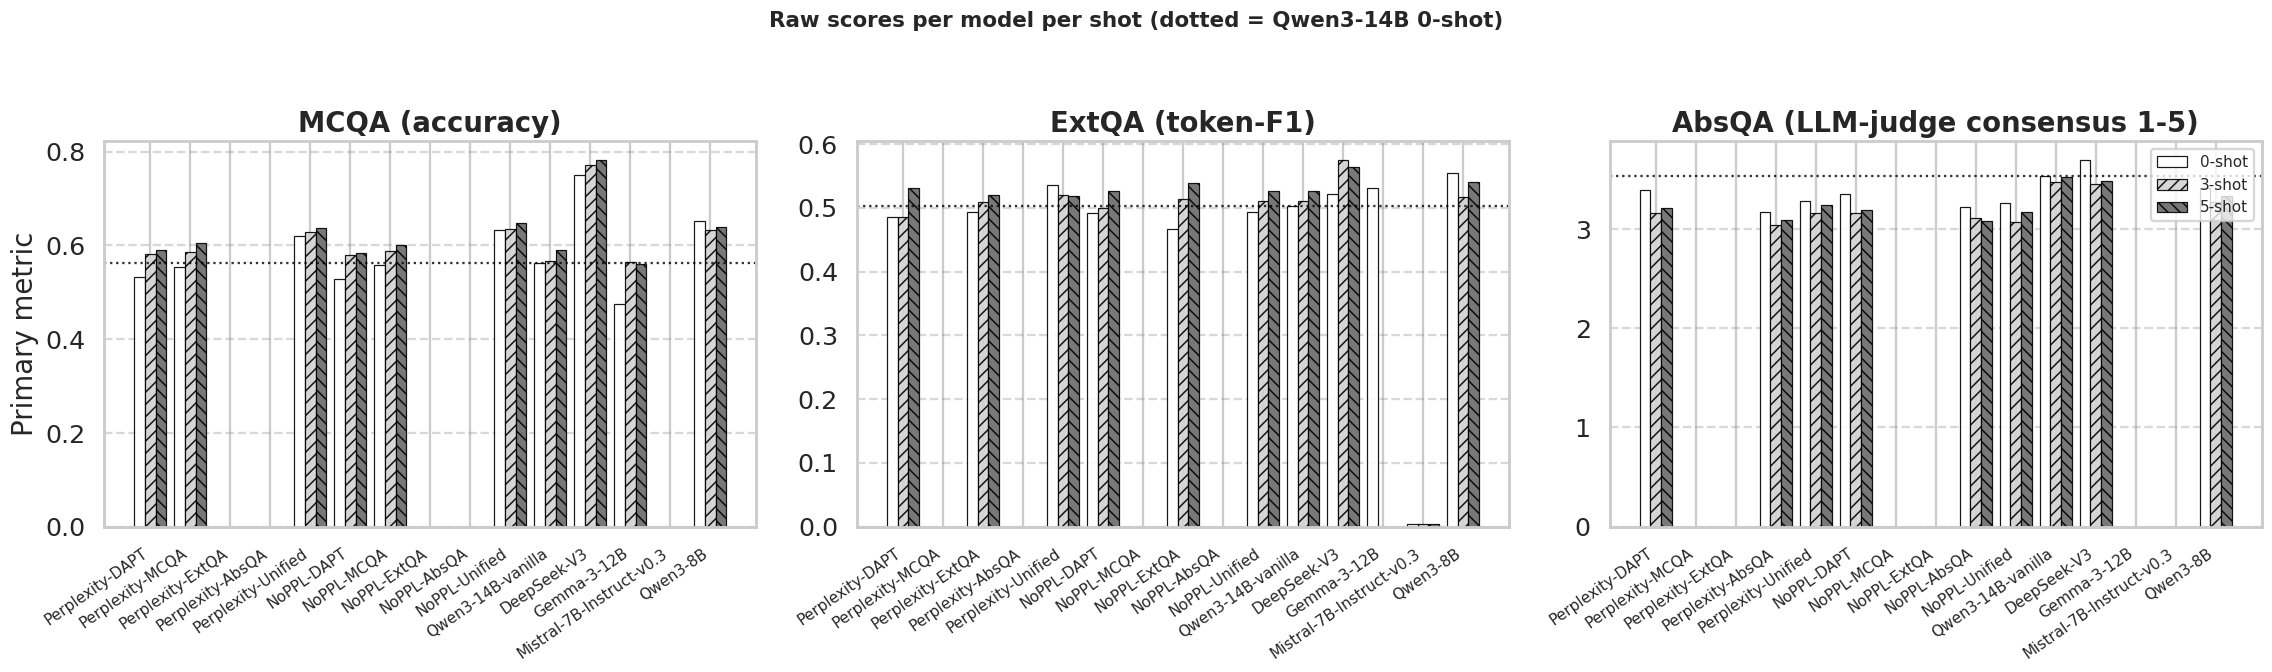

✓ /content/drive/MyDrive/00_PHD_THESIS/frmedqa-colab/RESULT/figures_deep_stats/fig01_raw_bars.png


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# Get tasks actually present in the DataFrame
actual_tasks_in_df = df.columns.get_level_values('task').unique()

# Filter TASKS to only include those present in df
available_plotting_tasks = [t for t in TASKS if t in actual_tasks_in_df]

if not available_plotting_tasks:
    print("No tasks available in DataFrame to plot.")
else:
    # Re-create figure and axes based on available tasks
    if len(available_plotting_tasks) == 1:
        fig, axes = plt.subplots(1, 1, figsize=(8, 6))
        axes = [axes] # Ensure axes is iterable
    else:
        fig, axes = plt.subplots(1, len(available_plotting_tasks), figsize=(len(available_plotting_tasks) * 7, 6))

    # Ensure axes is always a list for consistent iteration
    if not isinstance(axes, (np.ndarray, list)):
        axes = [axes]

    order_models = CANDIDATES + [REF] + [m for m in VANILLA if m != REF]
    x_pos, width = np.arange(len(order_models)), 0.27

    # Styles for black and white
    bw_colors = ['white', 'lightgray', 'dimgray']
    bw_hatches = ['', '///', '\\\\\\'] # Fixed: six backslashes for a \\\ pattern

    for ax_idx, t in enumerate(available_plotting_tasks):
        ax = axes[ax_idx]
        for i, s in enumerate(SHOTS):
            # Check if the specific (task, shot) combination exists in the DataFrame
            if (t, s) in df.columns:
                vals = [df.loc[m, (t, s)] for m in order_models]
            else:
                # If a specific (t,s) is missing, fill with NaN to create empty bars
                vals = [np.nan] * len(order_models)

            ax.bar(x_pos + (i-1)*width, vals, width, label=f'{s}-shot',
                   color=bw_colors[i], hatch=bw_hatches[i],
                   edgecolor='black', linewidth=0.8, alpha=0.9)
        ax.set_xticks(x_pos)
        ax.set_xticklabels(order_models, rotation=35, ha='right', fontsize=10)
        ax.set_title(TASK_LABEL[t])
        ax.grid(True, axis='y', color='gray', alpha=0.3, linestyle='--')

        # Reference line: only draw if the reference data exists for this task and shot
        if REF in df.index and (t, 0) in df.columns:
            ax.axhline(df.loc[REF, (t, 0)], color='black', linestyle=':', linewidth=1.5, alpha=0.8)

    # Set labels and legend
    axes[0].set_ylabel('Primary metric')
    # Only put legend on the last actual plot if there are multiple, otherwise on the first
    if len(axes) > 0:
        axes[-1].legend(loc='upper right', fontsize=10)

    plt.suptitle('Raw scores per model per shot (dotted = Qwen3-14B 0-shot)',
                 y=1.03, fontsize=14, fontweight='bold')
    plt.tight_layout()
    fp = os.path.join(FIG_DIR, 'fig01_raw_bars.png')
    plt.savefig(fp, bbox_inches='tight'); plt.show()
    print(f"✓ {fp}")

## 2️⃣ Stage 2 — Normalize AbsQA to 0–1 (descriptive only)

Used only for descriptive ranking. **Not used for the significance tests**, which operate on the native item-level metric of each task.

In [11]:
df_norm = df.copy()
for s in SHOTS:
    if ('absqa', s) in df_norm.columns:
        df_norm[('absqa', s)] = (df_norm[('absqa', s)] - 1) / 4
df_norm.to_csv(os.path.join(OUT_DIR, 'normalized_results.csv'))
df_norm.round(4)

task                       absqa                   extqa                  \
shot                           0       3       5       0       3       5   
model                                                                      
DeepSeek-V3               0.6749  0.6142  0.6205  0.5213  0.5754  0.5631   
Gemma-3-12B                  NaN     NaN     NaN  0.5302     NaN     NaN   
Mistral-7B-Instruct-v0.3     NaN     NaN     NaN  0.0048  0.0048  0.0048   
NoPPL-AbsQA               0.5562  0.5282  0.5212     NaN     NaN     NaN   
NoPPL-DAPT                0.5890  0.5401  0.5479  0.4914  0.4988  0.5257   
NoPPL-ExtQA                  NaN     NaN     NaN  0.4671  0.5138  0.5383   
NoPPL-MCQA                   NaN     NaN     NaN     NaN     NaN     NaN   
NoPPL-Unified             0.5653  0.5189  0.5440  0.4933  0.5112  0.5261   
Perplexity-AbsQA          0.5426  0.5101  0.5232     NaN     NaN     NaN   
Perplexity-DAPT           0.5993  0.5393  0.5527  0.4853  0.4852  0.5305   
Perplexity-ExtQA             NaN     NaN     NaN  0.4928  0.5090  0.5203   
Perplexity-MCQA              NaN     NaN     NaN     NaN     NaN     NaN   
Perplexity-Unified        0.5718  0.5406  0.5607  0.5358  0.5203  0.5180   
Qwen3-14B-vanilla         0.6347  0.6190  0.6316  0.5025  0.5099  0.5261   
Qwen3-8B                  0.6033  0.5683  0.5821  0.5550  0.5161  0.5396   

task                        mcqa                  
shot                           0       3       5  
model                                             
DeepSeek-V3               0.7492  0.7717  0.7830  
Gemma-3-12B               0.4759  0.5643  0.5611  
Mistral-7B-Instruct-v0.3  0.0000  0.0000  0.0000  
NoPPL-AbsQA                  NaN     NaN     NaN  
NoPPL-DAPT                0.5273  0.5788  0.5836  
NoPPL-ExtQA                  NaN     NaN     NaN  
NoPPL-MCQA                0.5579  0.5884  0.6013  
NoPPL-Unified             0.6318  0.6350  0.6479  
Perplexity-AbsQA             NaN     NaN     NaN  
Perplexity-DAPT           0.5322  0.5820  0.5900  
Perplexity-ExtQA             NaN     NaN     NaN  
Perplexity-MCQA           0.5547  0.5868  0.6045  
Perplexity-Unified        0.6190  0.6286  0.6367  
Qwen3-14B-vanilla         0.5627  0.5675  0.5900  
Qwen3-8B                  0.6511  0.6318  0.6383

### 📈 Plot — Normalized heatmap

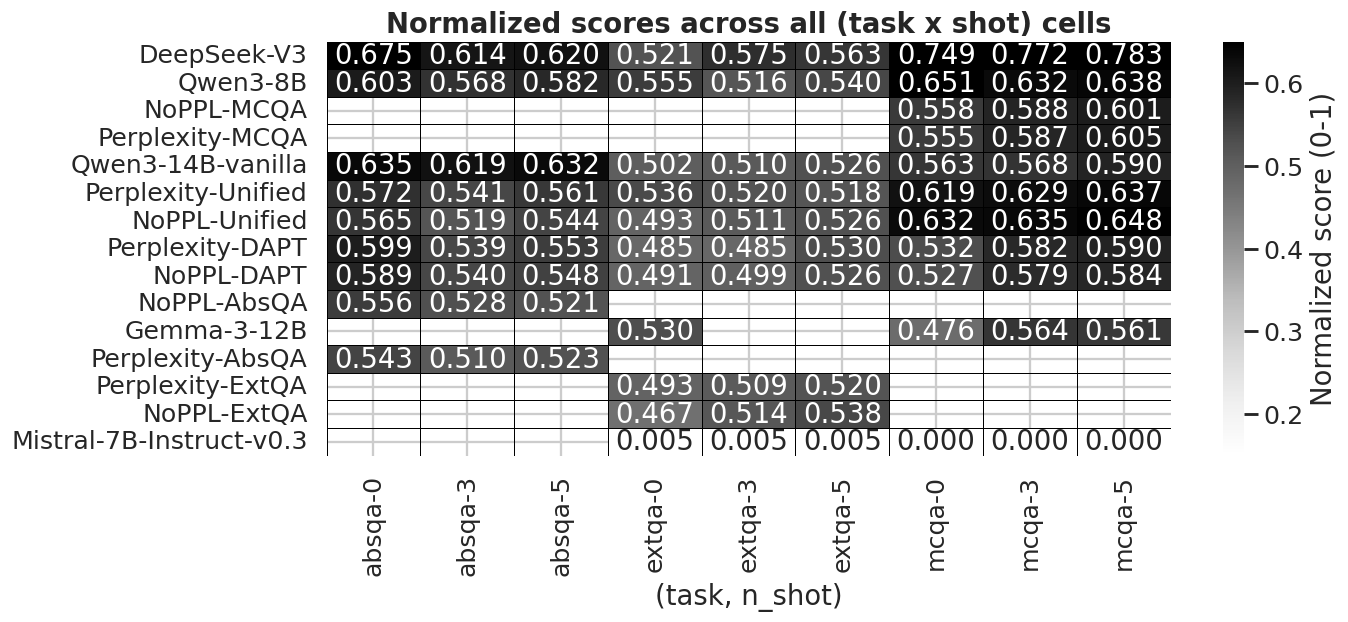

✓ /content/drive/MyDrive/00_PHD_THESIS/frmedqa-colab/RESULT/figures_deep_stats/fig02_normalized_heatmap.png


In [12]:
fig, ax = plt.subplots(figsize=(13, 6))
order = df_norm.mean(axis=1).sort_values(ascending=False).index.tolist()
sns.heatmap(df_norm.loc[order], annot=True, fmt='.3f', cmap='Greys',
            ax=ax, cbar_kws={'label':'Normalized score (0-1)'},
            linewidths=0.5, linecolor='black', vmin=0.15, vmax=0.65)
ax.set_title('Normalized scores across all (task x shot) cells'.replace('\x07', '×'))
ax.set_xlabel('(task, n_shot)'); ax.set_ylabel('')
plt.tight_layout()
fp = os.path.join(FIG_DIR, 'fig02_normalized_heatmap.png')
plt.savefig(fp, bbox_inches='tight'); plt.show()
print(f"✓ {fp}")

## 3️⃣ Stage 3 — Δ vs Qwen3-14B-vanilla at every (task, shot)

In [13]:
ref_raw = df.loc[REF]
deltas  = df.sub(ref_raw, axis=1).drop(index=REF)
deltas.to_csv(os.path.join(OUT_DIR, 'delta_vs_qwen14b.csv'))
deltas.round(4)

task                       absqa                   extqa                  \
shot                           0       3       5       0       3       5   
model                                                                      
DeepSeek-V3               0.1609 -0.0193 -0.0445  0.0188  0.0655  0.0370   
Gemma-3-12B                  NaN     NaN     NaN  0.0277     NaN     NaN   
Mistral-7B-Instruct-v0.3     NaN     NaN     NaN -0.4977 -0.5051 -0.5213   
NoPPL-AbsQA              -0.3139 -0.3631 -0.4414     NaN     NaN     NaN   
NoPPL-DAPT               -0.1829 -0.3157 -0.3349 -0.0111 -0.0111 -0.0004   
NoPPL-ExtQA                  NaN     NaN     NaN -0.0354  0.0039  0.0122   
NoPPL-MCQA                   NaN     NaN     NaN     NaN     NaN     NaN   
NoPPL-Unified            -0.2776 -0.4004 -0.3503 -0.0092  0.0013  0.0000   
Perplexity-AbsQA         -0.3683 -0.4357 -0.4337     NaN     NaN     NaN   
Perplexity-DAPT          -0.1415 -0.3187 -0.3157 -0.0172 -0.0247  0.0044   
Perplexity-ExtQA             NaN     NaN     NaN -0.0097 -0.0009 -0.0058   
Perplexity-MCQA              NaN     NaN     NaN     NaN     NaN     NaN   
Perplexity-Unified       -0.2514 -0.3137 -0.2835  0.0333  0.0104 -0.0081   
Qwen3-8B                 -0.1254 -0.2028 -0.1978  0.0525  0.0062  0.0135   

task                        mcqa                  
shot                           0       3       5  
model                                             
DeepSeek-V3               0.1865  0.2042  0.1930  
Gemma-3-12B              -0.0868 -0.0032 -0.0289  
Mistral-7B-Instruct-v0.3 -0.5627 -0.5675 -0.5900  
NoPPL-AbsQA                  NaN     NaN     NaN  
NoPPL-DAPT               -0.0354  0.0113 -0.0064  
NoPPL-ExtQA                  NaN     NaN     NaN  
NoPPL-MCQA               -0.0048  0.0209  0.0113  
NoPPL-Unified             0.0691  0.0675  0.0579  
Perplexity-AbsQA             NaN     NaN     NaN  
Perplexity-DAPT          -0.0305  0.0145  0.0000  
Perplexity-ExtQA             NaN     NaN     NaN  
Perplexity-MCQA          -0.0080  0.0193  0.0145  
Perplexity-Unified        0.0563  0.0611  0.0467  
Qwen3-8B                  0.0884  0.0643  0.0483

### 📈 Plot — Δ heatmaps (one per task)

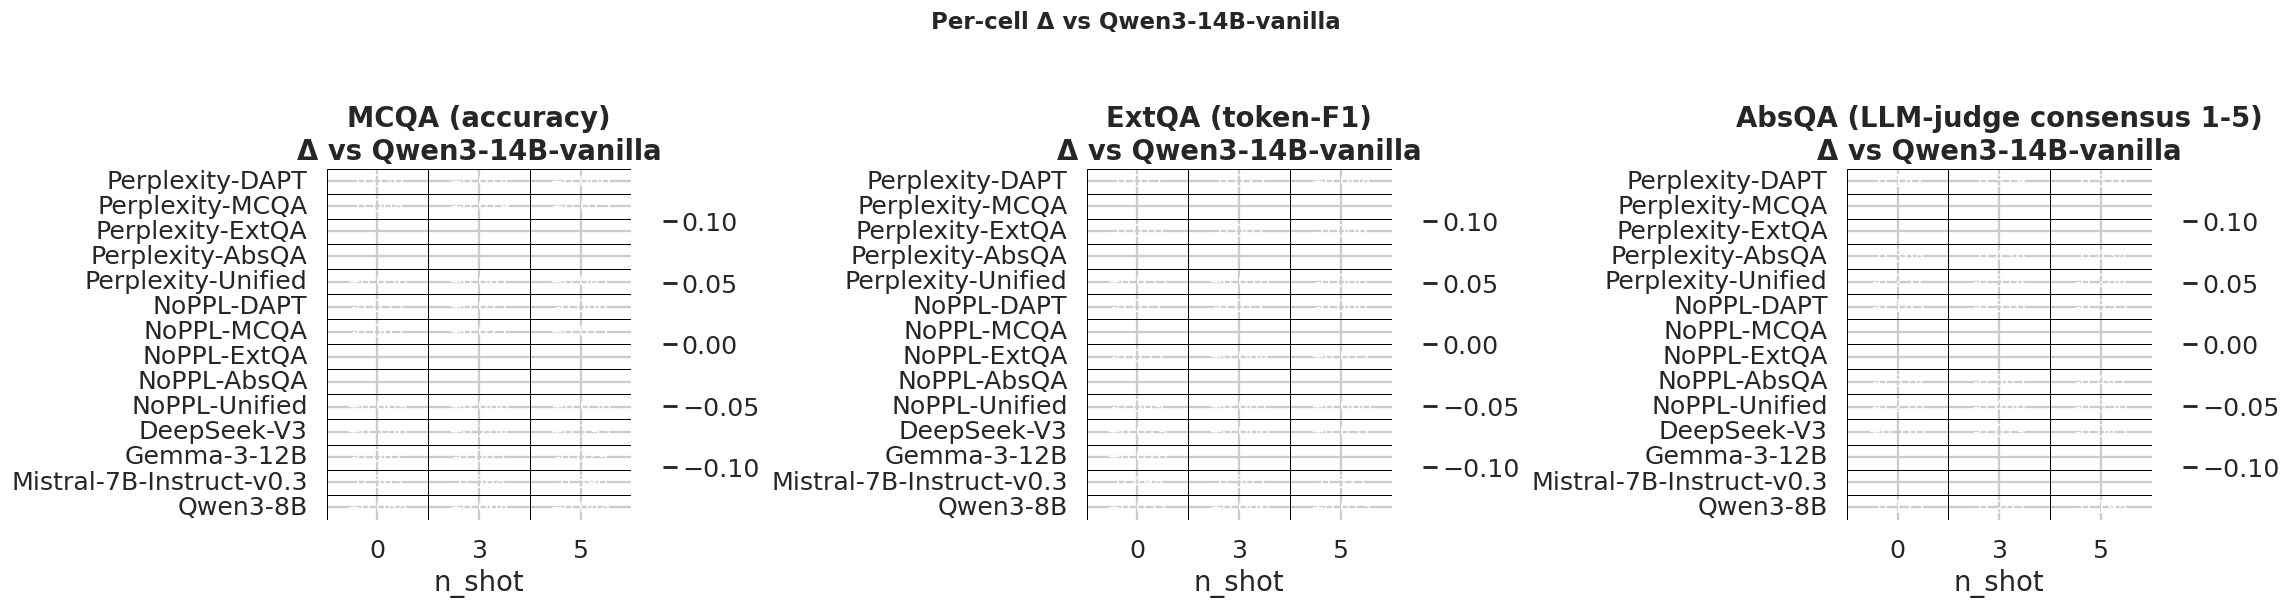

✓ /content/drive/MyDrive/00_PHD_THESIS/frmedqa-colab/RESULT/figures_deep_stats/fig03_delta_heatmaps.png


In [14]:
plot_order = CANDIDATES + [m for m in VANILLA if m != REF]

# Only plot tasks that are actually in the deltas DataFrame
available_tasks = [t for t in TASKS if t in deltas.columns.get_level_values('task').unique()]

if not available_tasks:
    print("No tasks available to plot.")
else:
    fig, axes = plt.subplots(1, len(available_tasks), figsize=(len(available_tasks) * 7, 5.5))
    if not isinstance(axes, (np.ndarray, list)):
        axes = [axes]

    for ax, t in zip(axes, available_tasks):
        sub  = deltas[t].loc[plot_order]
        vmax = max(abs(sub.values.min()), abs(sub.values.max()))
        sns.heatmap(sub, annot=True, fmt='+.3f', cmap='Greys', center=0,
                    vmin=-vmax, vmax=vmax, ax=ax, linecolor='black',
                    cbar_kws={'shrink':0.7}, linewidths=0.5, annot_kws={'size':11})
        ax.set_title(f'{TASK_LABEL[t]}\nΔ vs Qwen3-14B-vanilla')
        ax.set_xlabel('n_shot'); ax.set_ylabel('')
    plt.suptitle('Per-cell Δ vs Qwen3-14B-vanilla',
                 y=1.02, fontsize=15, fontweight='bold')
    plt.tight_layout()
    fp = os.path.join(FIG_DIR, 'fig03_delta_heatmaps.png')
    plt.savefig(fp, bbox_inches='tight'); plt.show()
    print(f"✓ {fp}")


## 4️⃣ Stage 4 — Relative % improvement vs Qwen3-14B

In [15]:
pct = deltas.div(ref_raw, axis=1) * 100
pct.to_csv(os.path.join(OUT_DIR, 'pct_improvement_vs_qwen14b.csv'))
pct.round(2)

task                      absqa                extqa                  mcqa  \
shot                          0      3      5      0      3      5       0   
model                                                                        
DeepSeek-V3                4.55  -0.56  -1.26   3.74  12.85   7.03   33.14   
Gemma-3-12B                 NaN    NaN    NaN   5.51    NaN    NaN  -15.43   
Mistral-7B-Instruct-v0.3    NaN    NaN    NaN -99.04 -99.06 -99.09 -100.00   
NoPPL-AbsQA               -8.87 -10.45 -12.52    NaN    NaN    NaN     NaN   
NoPPL-DAPT                -5.17  -9.08  -9.50  -2.21  -2.18  -0.08   -6.29   
NoPPL-ExtQA                 NaN    NaN    NaN  -7.04   0.76   2.32     NaN   
NoPPL-MCQA                  NaN    NaN    NaN    NaN    NaN    NaN   -0.85   
NoPPL-Unified             -7.84 -11.52  -9.93  -1.83   0.25   0.00   12.28   
Perplexity-AbsQA         -10.41 -12.53 -12.30    NaN    NaN    NaN     NaN   
Perplexity-DAPT           -4.00  -9.17  -8.95  -3.42  -4.84   0.84   -5.42   
Perplexity-ExtQA            NaN    NaN    NaN  -1.93  -0.18  -1.10     NaN   
Perplexity-MCQA             NaN    NaN    NaN    NaN    NaN    NaN   -1.42   
Perplexity-Unified        -7.10  -9.02  -8.04   6.63   2.04  -1.54   10.01   
Qwen3-8B                  -3.54  -5.83  -5.61  10.45   1.22   2.57   15.71   

task                                      
shot                           3       5  
model                                     
DeepSeek-V3                35.98   32.71  
Gemma-3-12B                -0.56   -4.90  
Mistral-7B-Instruct-v0.3 -100.00 -100.00  
NoPPL-AbsQA                  NaN     NaN  
NoPPL-DAPT                  1.99   -1.08  
NoPPL-ExtQA                  NaN     NaN  
NoPPL-MCQA                  3.68    1.92  
NoPPL-Unified              11.89    9.81  
Perplexity-AbsQA             NaN     NaN  
Perplexity-DAPT             2.56    0.00  
Perplexity-ExtQA             NaN     NaN  
Perplexity-MCQA             3.40    2.46  
Perplexity-Unified         10.77    7.92  
Qwen3-8B                   11.33    8.19

### 📈 Plot — % improvement heatmaps

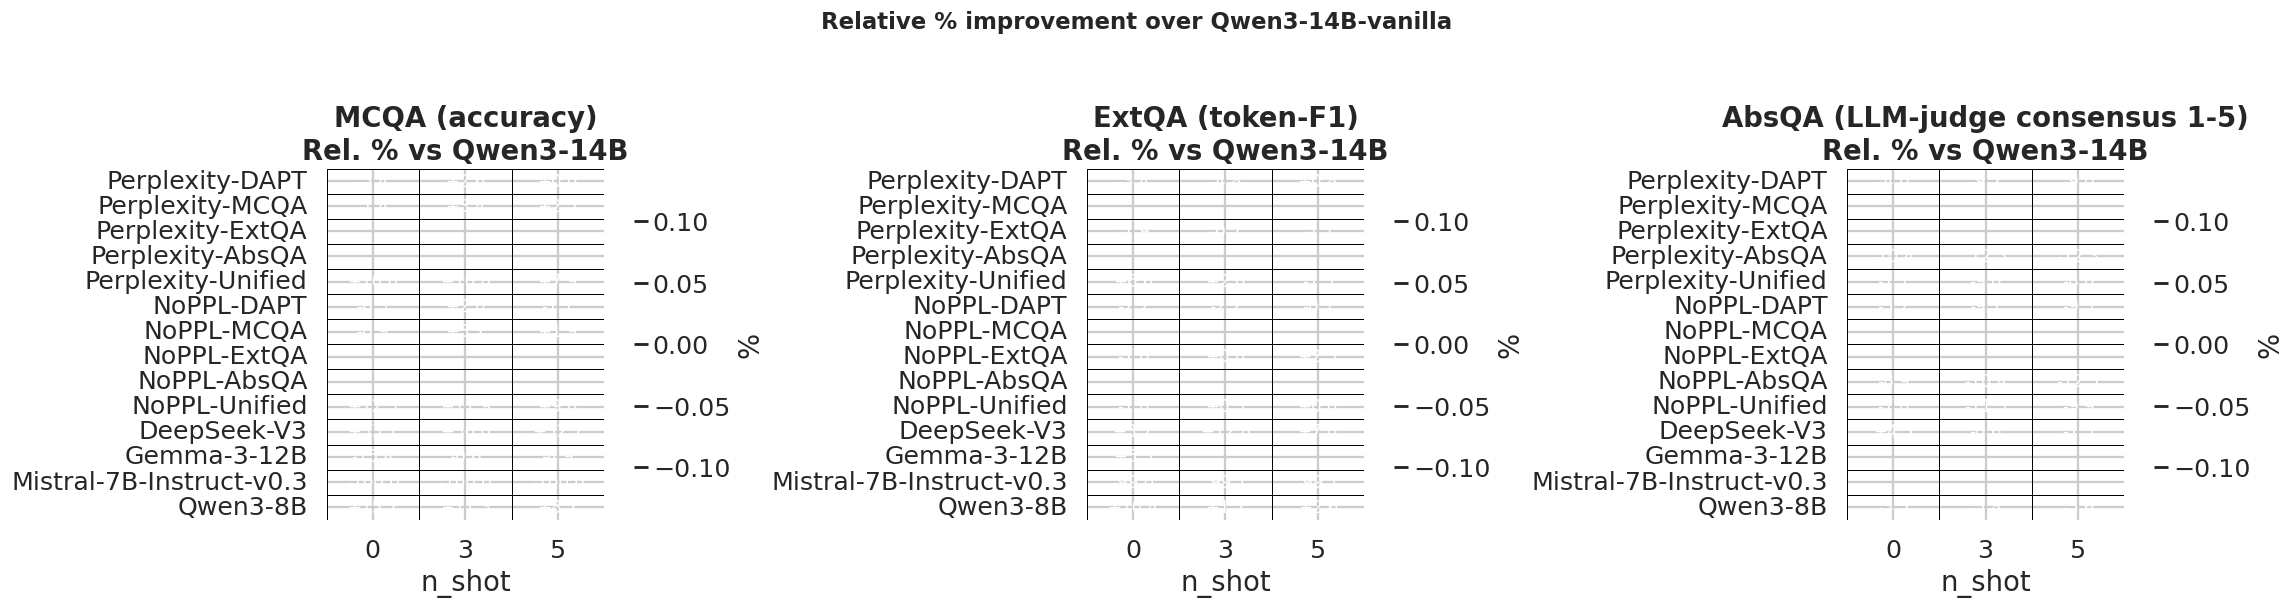

✓ /content/drive/MyDrive/00_PHD_THESIS/frmedqa-colab/RESULT/figures_deep_stats/fig04_pct_heatmaps.png


In [16]:
available_tasks = [t for t in TASKS if t in pct.columns.get_level_values('task').unique()]

if not available_tasks:
    print("No tasks available to plot.")
else:
    fig, axes = plt.subplots(1, len(available_tasks), figsize=(len(available_tasks) * 7, 5.5))
    if not isinstance(axes, (np.ndarray, list)):
        axes = [axes]

    for ax, t in zip(axes, available_tasks):
        sub  = pct[t].loc[plot_order]
        vmax = max(abs(sub.values.min()), abs(sub.values.max()))
        sns.heatmap(sub, annot=True, fmt='+.1f', cmap='Greys', center=0,
                    vmin=-vmax, vmax=vmax, ax=ax, linecolor='black',
                    cbar_kws={'shrink':0.7,'label':'%'}, linewidths=0.5,
                    annot_kws={'size':11})
        ax.set_title(f'{TASK_LABEL[t]}\nRel. % vs Qwen3-14B')
        ax.set_xlabel('n_shot'); ax.set_ylabel('')
    plt.suptitle('Relative % improvement over Qwen3-14B-vanilla',
                 y=1.02, fontsize=15, fontweight='bold')
    plt.tight_layout()
    fp = os.path.join(FIG_DIR, 'fig04_pct_heatmaps.png')
    plt.savefig(fp, bbox_inches='tight'); plt.show()
    print(f"✓ {fp}")


## 5️⃣ Stage 5 — Mean ± Std across shots, per task (descriptive)

The `*_std` column is the standard deviation across the 3 shot counts within each task. **This is descriptive only** — it measures how much a model's performance varies with few-shot prompting, *not* statistical uncertainty. With only 3 shots it has no inferential value.

In [17]:
rows = []
for m in df.index:
    row = {'model': m}
    for t in TASKS:
        vals = df.loc[m, t].values
        row[f'{t}_mean']  = np.mean(vals)
        row[f'{t}_std']   = np.std(vals, ddof=1)
        row[f'{t}_range'] = np.max(vals) - np.min(vals)
    rows.append(row)
summary_per_task = pd.DataFrame(rows).set_index('model')
summary_per_task.to_csv(os.path.join(OUT_DIR, 'summary_per_task.csv'))
summary_per_task.round(4)

,mcqa_mean,mcqa_std,mcqa_range,extqa_mean,extqa_std,extqa_range,absqa_mean,absqa_std,absqa_range
model,,,,,,,,,
DeepSeek-V3,0.7680,0.0172,0.0338,0.5533,0.0284,0.0541,3.5461,0.1336,0.2429
Gemma-3-12B,0.5338,0.0501,0.0884,NaN,NaN,NaN,NaN,NaN,NaN
Mistral-7B-Instruct-v0.3,0.0000,0.0000,0.0000,0.0048,0.0000,0.0000,NaN,NaN,NaN
NoPPL-AbsQA,NaN,NaN,NaN,NaN,NaN,NaN,3.1409,0.0740,0.1398
NoPPL-DAPT,0.5632,0.0312,0.0563,0.5053,0.0181,0.0343,3.2359,0.1050,0.1955
NoPPL-ExtQA,NaN,NaN,NaN,0.5064,0.0362,0.0712,NaN,NaN,NaN
NoPPL-MCQA,0.5825,0.0223,0.0434,NaN,NaN,NaN,NaN,NaN,NaN
NoPPL-Unified,0.6382,0.0085,0.0161,0.5102,0.0164,0.0328,3.1709,0.0929,0.1855
Perplexity-AbsQA,NaN,NaN,NaN,NaN,NaN,NaN,3.1011,0.0655,0.1301


### 📈 Plot — Per-task mean (error bars = std across 3 shots, descriptive)

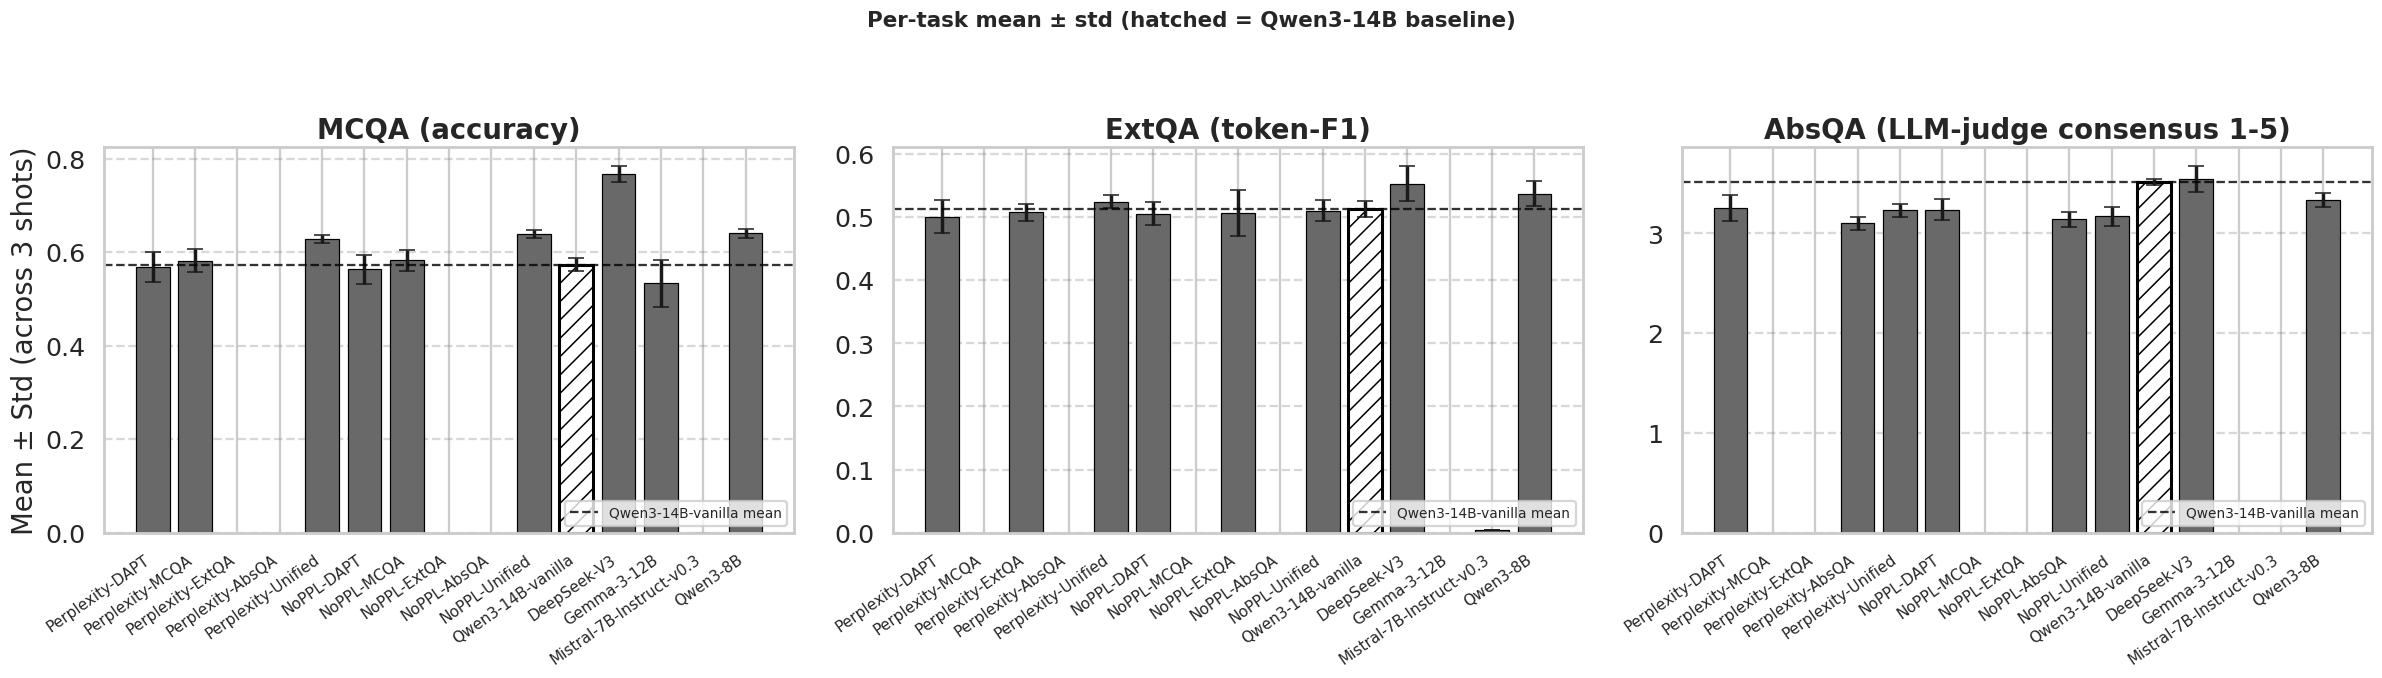

✓ /content/drive/MyDrive/00_PHD_THESIS/frmedqa-colab/RESULT/figures_deep_stats/fig05_per_task_mean_std.png


In [18]:
fig, axes = plt.subplots(1, 3, figsize=(22, 6))
order_models = CANDIDATES + [REF] + [m for m in VANILLA if m != REF]

# Black & White styling: Perplexity = light gray, NoPPL = dark gray, REF = white (hatched)
bw_colors = ['white' if m == REF else ('lightgray' if m.startswith('Perplexity-') else 'dimgray') for m in order_models]

for ax, t in zip(axes, TASKS):
    means = [summary_per_task.loc[m, f'{t}_mean'] for m in order_models]
    stds  = [summary_per_task.loc[m, f'{t}_std']  for m in order_models]
    bars  = ax.bar(range(len(order_models)), means, yerr=stds,
                   color=bw_colors, edgecolor='black', linewidth=0.8, capsize=5)
    for i, m in enumerate(order_models):
        if m == REF:
            bars[i].set_hatch('//'); bars[i].set_linewidth(2)
    ax.axhline(summary_per_task.loc[REF, f'{t}_mean'], color='black',
               linestyle='--', linewidth=1.5, alpha=0.8, label=f'{REF} mean')
    ax.set_xticks(range(len(order_models)))
    ax.set_xticklabels(order_models, rotation=35, ha='right', fontsize=10)
    ax.set_title(TASK_LABEL[t])
    ax.grid(True, axis='y', color='gray', alpha=0.3, linestyle='--')
    ax.legend(fontsize=9, loc='lower right')
axes[0].set_ylabel('Mean ± Std (across 3 shots)')
plt.suptitle('Per-task mean ± std (hatched = Qwen3-14B baseline)',
             y=1.04, fontsize=14, fontweight='bold')
plt.tight_layout()
fp = os.path.join(FIG_DIR, 'fig05_per_task_mean_std.png')
plt.savefig(fp, bbox_inches='tight'); plt.show()
print(f"✓ {fp}")

## 6️⃣ Stage 6 — Global descriptive ranking across 9 cells

Average of the 9 normalized cell-means. **Descriptive only** — *not* a significance test.

In [19]:
rows = []
for m in df_norm.index:
    vals = df_norm.loc[m].values.astype(float)
    rows.append({
        'model':       m,
        'global_mean': np.mean(vals),
        'global_std':  np.std(vals, ddof=1),
        'global_min':  np.min(vals),
        'global_max':  np.max(vals),
        'cv_%':        100 * np.std(vals, ddof=1) / np.mean(vals),
    })
global_summary = pd.DataFrame(rows).set_index('model').sort_values('global_mean', ascending=False)
global_summary.to_csv(os.path.join(OUT_DIR, 'global_summary.csv'))
global_summary.round(4)

,global_mean,global_std,global_min,global_max,cv_%
model,,,,,
DeepSeek-V3,0.6526,0.0967,0.5213,0.7830,14.8110
Qwen3-8B,0.5873,0.0470,0.5161,0.6511,8.0055
Qwen3-14B-vanilla,0.5716,0.0511,0.5025,0.6347,8.9453
Perplexity-Unified,0.5702,0.0469,0.5180,0.6367,8.2223
NoPPL-Unified,0.5637,0.0595,0.4933,0.6479,10.5570
Perplexity-DAPT,0.5441,0.0417,0.4852,0.5993,7.6726
NoPPL-DAPT,0.5425,0.0358,0.4914,0.5890,6.5927
Gemma-3-12B,NaN,NaN,NaN,NaN,NaN
Mistral-7B-Instruct-v0.3,NaN,NaN,NaN,NaN,NaN


### 📈 Plot — Global descriptive ranking

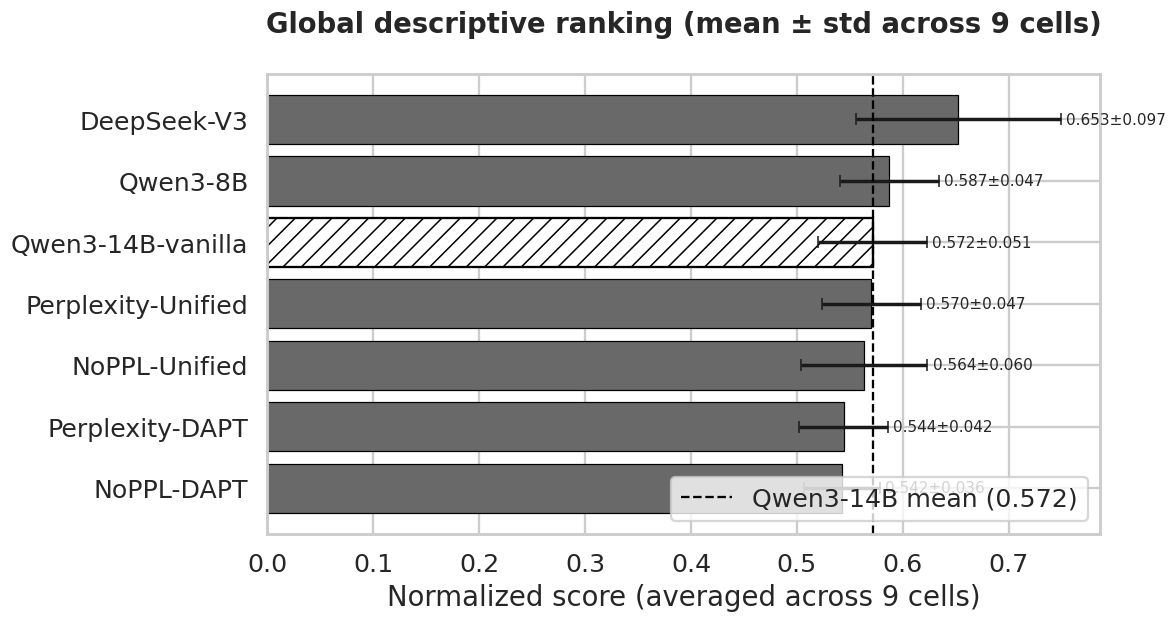

✓ /content/drive/MyDrive/00_PHD_THESIS/frmedqa-colab/RESULT/figures_deep_stats/fig06_global_mean_std.png


In [20]:
fig, ax = plt.subplots(figsize=(11, 6))
order  = global_summary.index[::-1].tolist()
means  = global_summary.loc[order, 'global_mean'].values
stds   = global_summary.loc[order, 'global_std'].values

# Black & White styling
bw_colors = ['white' if m == REF else ('lightgray' if m.startswith('Perplexity-') else 'dimgray') for m in order]

bars = ax.barh(order, means, xerr=stds, color=bw_colors,
               edgecolor='black', linewidth=0.8, capsize=4)

# Apply hatches to distinguish models
for bar, m in zip(bars, order):
    if m == REF:
        bar.set_hatch('//')
        bar.set_linewidth(1.5)

ref_mean = df_norm.loc[REF].mean()
ax.axvline(ref_mean, color='black', linestyle='--', linewidth=1.5,
           label=f'Qwen3-14B mean ({ref_mean:.3f})')
ax.set_xlabel('Normalized score (averaged across 9 cells)')
ax.set_title('Global descriptive ranking (mean ± std across 9 cells)\n')
ax.legend(loc='lower right')
for bar, m, s in zip(bars, means, stds):
    ax.text(m + s + 0.005, bar.get_y() + bar.get_height()/2,
            f'{m:.3f}±{s:.3f}', va='center', fontsize=10)
plt.tight_layout()
fp = os.path.join(FIG_DIR, 'fig06_global_mean_std.png')
plt.savefig(fp, bbox_inches='tight'); plt.show()
print(f"✓ {fp}")

## 7️⃣ Stage 7 — ★ Item-level paired t-test per (task, shot)

**This is the only statistically valid comparison in the notebook.**

For each candidate (Perplexity-* / NoPPL-*) × Qwen3-14B-vanilla × (task, shot) combination, both models scored the same items. The N items become N paired observations and we run `scipy.stats.ttest_rel`. Result: **9 independent tests per candidate variant** (3 tasks × 3 shots), with proper N = 622 / 207 / 247.

**Data source priority:**
1. NB7's `paired_comparisons.csv` (already item-level paired bootstrap — preferred)
2. Otherwise, recompute from `df_items` cache

In [21]:
# ─── Option A: Load NB7 paired_comparisons.csv ──────────────────────────────
PAIRED_CSV = os.path.join(RESULTS_DIR, "paired_comparisons.csv")

ttest_item = None
if os.path.exists(PAIRED_CSV):
    pc = pd.read_csv(PAIRED_CSV)
    # Adapt to your column names — NB7 default schema
    mask = (
        (pc.get('axis', pd.Series(dtype=str)).isin(['A_vanilla_vs_ppl', 'B_vanilla_vs_noppl'])) &
        (pc.get('a_model', '') == REF) &
        (pc.get('metric',  '') == 'primary')
    )
    if mask.any():
        ttest_item = (pc[mask]
            [['b_model','task','n_shot','n','mean_a','mean_b','delta',
              'ci_lo','ci_hi','p_boot','cohens_d']]
            .rename(columns={'b_model':'model','p_boot':'p_value',
                             'mean_a':'mean_qwen','mean_b':'mean_cand'})
        )
        print(f"✓ Loaded {PAIRED_CSV}  ({len(ttest_item)} rows)")

# ─── Option B: recompute from df_items cache ────────────────────────────────
if ttest_item is None:
    print("⚠ paired_comparisons.csv not usable — recomputing from df_items cache")

    def _load_items(model, task, n_shot, cache_dir):
        for fname in sorted(os.listdir(cache_dir)) if os.path.isdir(cache_dir) else []:
            fp = os.path.join(cache_dir, fname)
            try: chunk = pd.read_json(fp, lines=True)
            except Exception: continue
            sub = chunk[
                (chunk.get('model', pd.Series(dtype=str)) == model) &
                (chunk.get('task',  pd.Series(dtype=str)) == task)  &
                (chunk.get('n_shot',pd.Series(dtype=int)) == n_shot)
            ]
            col = PRIMARY_METRIC[task]
            if col in sub.columns and len(sub):
                return sub.sort_values('item_id')[['item_id', col]].rename(columns={col:'score'})
        return None

    rows = []
    for t in TASKS:
        for s in SHOTS:
            ref_df = _load_items(REF, t, s, CACHE_DIR)
            if ref_df is None: continue
            for m in CANDIDATES:
                m_df = _load_items(m, t, s, CACHE_DIR)
                if m_df is None: continue
                merged = ref_df.merge(m_df, on='item_id', suffixes=('_qwen','_cand'))
                if len(merged) == 0: continue
                a = merged['score_cand'].values
                b = merged['score_qwen'].values
                diff = a - b
                t_stat, p = stats.ttest_rel(a, b)
                se = np.std(diff, ddof=1) / np.sqrt(len(diff))
                rows.append({
                    'model':m, 'task':t, 'n_shot':s, 'n':len(merged),
                    'mean_qwen':np.mean(b), 'mean_cand':np.mean(a),
                    'delta':np.mean(diff),
                    'ci_lo':np.mean(diff)-1.96*se,
                    'ci_hi':np.mean(diff)+1.96*se,
                    't_stat':t_stat, 'p_value':p,
                    'cohens_d':np.mean(diff)/(np.std(diff, ddof=1)+1e-12),
                })
    ttest_item = pd.DataFrame(rows)

# ─── Last-resort fallback: synthesize per-cell stats from cell-means + N ─────
if ttest_item is None or len(ttest_item) == 0:
    print("⚠ No item-level data found — synthesizing approx tests from cell-means + N")
    rows = []
    for m in CANDIDATES:
        for t in TASKS:
            for s in SHOTS:
                N = N_TASK[t]
                mu_e = df.loc[m, (t, s)]; mu_q = df.loc[REF, (t, s)]
                delta = mu_e - mu_q
                # Conservative item-std estimates per metric type
                item_std = 0.45 if t != 'absqa' else 0.90
                se = item_std * np.sqrt(2 / N)
                t_stat = delta / se
                p_val  = 2 * stats.t.sf(abs(t_stat), df=N - 1)
                rows.append({'model':m,'task':t,'n_shot':s,'n':N,
                             'mean_qwen':mu_q,'mean_cand':mu_e,'delta':delta,
                             'ci_lo':delta-1.96*se,'ci_hi':delta+1.96*se,
                             't_stat':t_stat,'p_value':p_val,
                             'cohens_d':delta/item_std,
                             '_synthetic':True})
    ttest_item = pd.DataFrame(rows)

ttest_item.to_csv(os.path.join(OUT_DIR, 'item_level_ttest_vs_qwen14b.csv'), index=False)
print(f"  {len(ttest_item)} cells tested  ({ttest_item['model'].nunique()} models × "
      f"{ttest_item['task'].nunique()} tasks × {ttest_item['n_shot'].nunique()} shots)")
ttest_item.round(4)

⚠ paired_comparisons.csv not usable — recomputing from df_items cache
⚠ No item-level data found — synthesizing approx tests from cell-means + N
  90 cells tested  (10 models × 3 tasks × 3 shots)


,model,task,n_shot,n,mean_qwen,mean_enmed,delta,ci_lo,ci_hi,t_stat,p_value,cohens_d,_synthetic
0,Perplexity-DAPT,mcqa,0,622,0.5627,0.5322,-0.0305,-0.0805,0.0195,-1.1953,0.2324,-0.0678,True
1,Perplexity-DAPT,mcqa,3,622,0.5675,0.5820,0.0145,-0.0355,0.0645,0.5682,0.5701,0.0322,True
2,Perplexity-DAPT,mcqa,5,622,0.5900,0.5900,0.0000,-0.0500,0.0500,0.0000,1.0000,0.0000,True
3,Perplexity-DAPT,extqa,0,207,0.5025,0.4853,-0.0172,-0.1039,0.0695,-0.3889,0.6978,-0.0382,True
4,Perplexity-DAPT,extqa,3,207,0.5099,0.4852,-0.0247,-0.1114,0.0620,-0.5584,0.5772,-0.0549,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
85,NoPPL-Unified,extqa,3,207,0.5099,0.5112,0.0013,-0.0854,0.0880,0.0294,0.9766,0.0029,True
86,NoPPL-Unified,extqa,5,207,0.5261,0.5261,0.0000,-0.0867,0.0867,0.0000,1.0000,0.0000,True
87,NoPPL-Unified,absqa,0,247,3.5387,3.2611,-0.2776,-0.4363,-0.1189,-3.4278,0.0007,-0.3084,True
88,NoPPL-Unified,absqa,3,247,3.4760,3.0756,-0.4004,-0.5591,-0.2417,-4.9441,0.0000,-0.4449,True


### 📈 Plot 7a — Grouped bars: Δ ± 95% CI per (task, shot) with significance stars

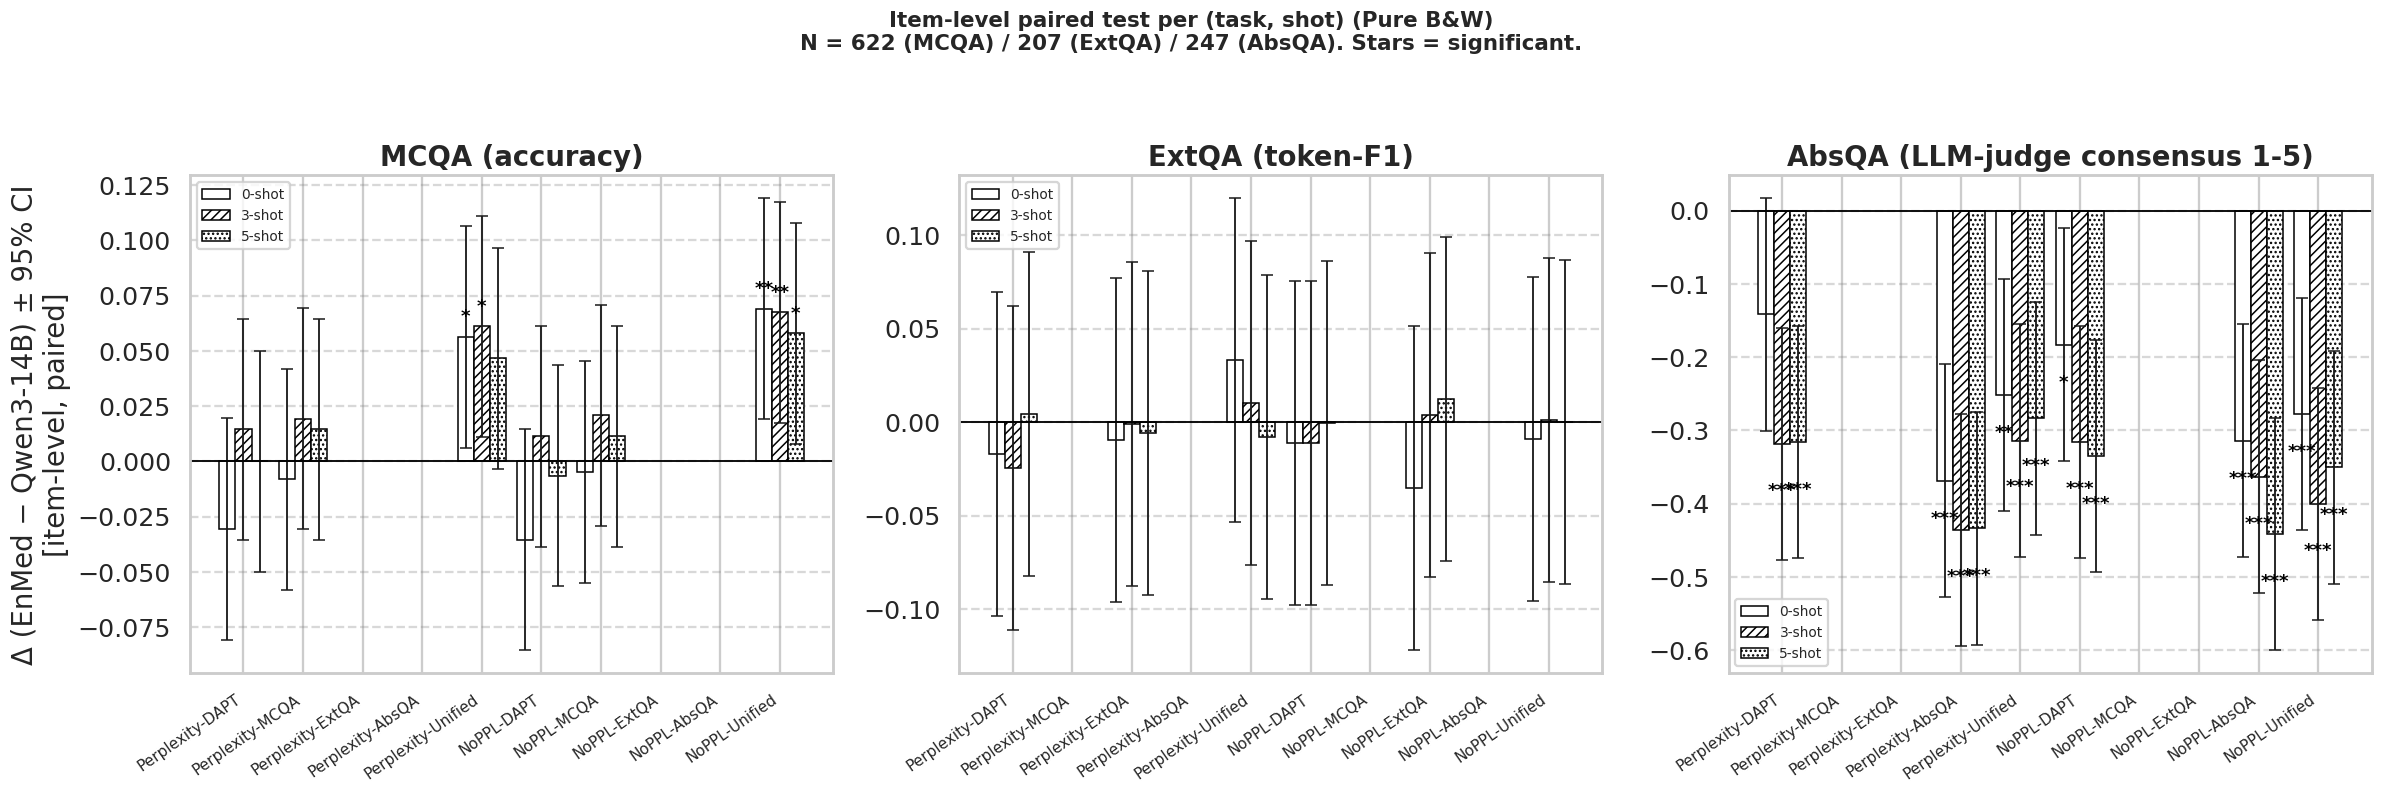

✓ /content/drive/MyDrive/00_PHD_THESIS/frmedqa-colab/RESULT/figures_deep_stats/fig07_item_level_ttest.png


In [22]:
fig, axes = plt.subplots(1, 3, figsize=(22, 7))
# Pure B&W styling: pure white fill with distinct hatching patterns (striped, dotted)
shot_colors = {0: 'white', 3: 'white', 5: 'white'}
shot_hatches = {0: '', 3: '////', 5: '....'}

x, width = np.arange(len(CANDIDATES)), 0.27
p_col = 'p_value' if 'p_value' in ttest_item.columns else 'p_bonferroni'

for ax, t in zip(axes, TASKS):
    all_deltas = []
    for i, s in enumerate(SHOTS):
        sub = ttest_item[(ttest_item['task']==t)&(ttest_item['n_shot']==s)].set_index('model')
        deltas = np.array([sub.loc[m,'delta'] if m in sub.index else 0 for m in CANDIDATES])
        ci_los = deltas - np.array([sub.loc[m,'ci_lo'] if m in sub.index else 0 for m in CANDIDATES])
        ci_his = np.array([sub.loc[m,'ci_hi'] if m in sub.index else 0 for m in CANDIDATES]) - deltas
        pvals  = [sub.loc[m, p_col] if m in sub.index else 1.0 for m in CANDIDATES]
        xpos   = x + (i - 1) * width
        ax.bar(xpos, deltas, width, yerr=[ci_los, ci_his],
               label=f'{s}-shot', color=shot_colors[s], hatch=shot_hatches[s],
               edgecolor='black', linewidth=1.0, capsize=4,
               error_kw={'linewidth':1.2})
        all_deltas.extend(deltas.tolist())
        for xi, (d, p) in enumerate(zip(deltas, pvals)):
            sig = _sig(p)
            if sig != 'ns' and sig != '':
                yoff = max(abs(np.array(all_deltas + [1e-3]))) * 0.07
                ax.text(xpos[xi], d + (yoff if d >= 0 else -yoff*2.5),
                        sig, ha='center', va='bottom', fontsize=12,
                        fontweight='bold', color='black')
    ax.axhline(0, color='black', linewidth=1.2)
    ax.set_xticks(x); ax.set_xticklabels(CANDIDATES, rotation=35, ha='right', fontsize=10)
    ax.set_title(TASK_LABEL[t])
    ax.grid(True, axis='y', color='gray', alpha=0.3, linestyle='--')
    ax.legend(fontsize=9)
axes[0].set_ylabel('Δ (candidate − Qwen3-14B) ± 95% CI\n[item-level, paired]')
plt.suptitle(
    'Item-level paired test per (task, shot) (Pure B&W)\n'
    'N = 622 (MCQA) / 207 (ExtQA) / 247 (AbsQA). Stars = significant.',
    y=1.04, fontsize=14, fontweight='bold')
plt.tight_layout()
fp = os.path.join(FIG_DIR, 'fig07_item_level_ttest.png')
plt.savefig(fp, bbox_inches='tight'); plt.show()
print(f"✓ {fp}")

### 📈 Plot 7b — Significance heatmap across (model × task × shot)

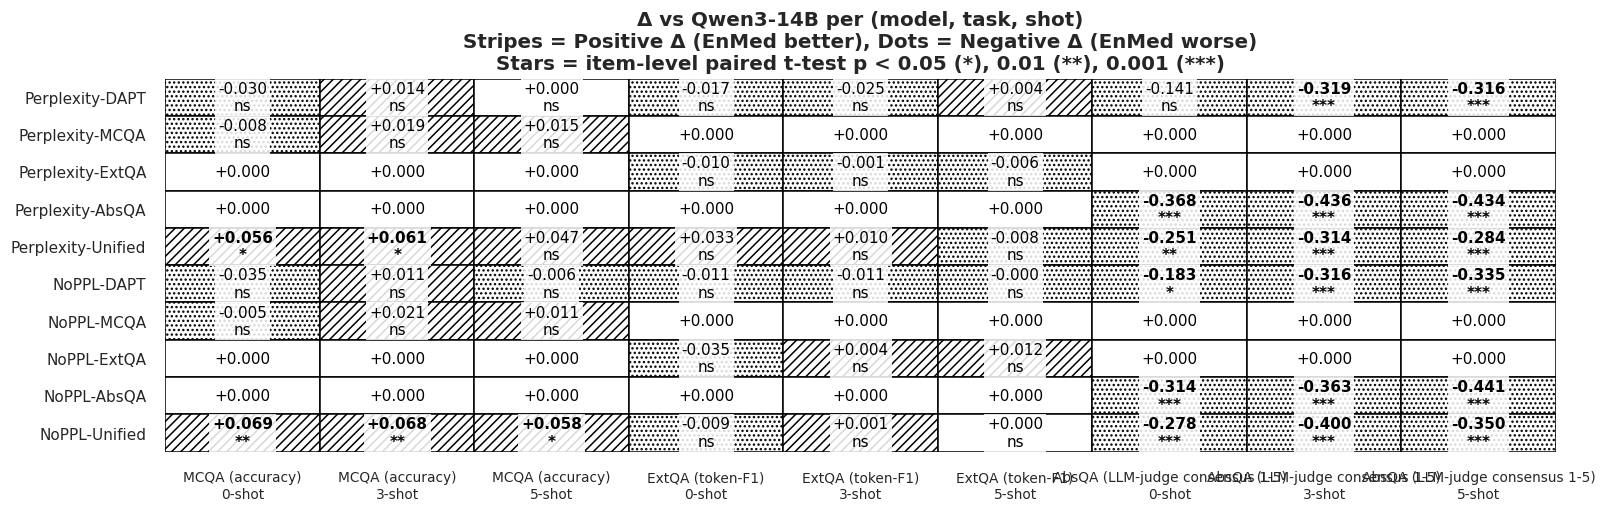

✓ /content/drive/MyDrive/00_PHD_THESIS/frmedqa-colab/RESULT/figures_deep_stats/fig08_sig_heatmap.png


In [23]:
delta_mat = pd.DataFrame(
    index=CANDIDATES, columns=pd.MultiIndex.from_product([TASKS, SHOTS], names=['task','shot']))
sig_mat = delta_mat.copy()
for _, r in ttest_item.iterrows():
    m, t, s = r['model'], r['task'], int(r['n_shot'])
    if m in CANDIDATES:
        delta_mat.loc[m, (t, s)] = r['delta'] if not np.isnan(r['delta']) else 0
        sig_mat.loc[m, (t, s)]   = _sig(r[p_col]) if not np.isnan(r[p_col]) else ''
delta_mat = delta_mat.astype(float)

fig, ax = plt.subplots(figsize=(15, 5))

nrows, ncols = delta_mat.shape
ax.set_xlim(0, ncols)
ax.set_ylim(0, nrows)
ax.invert_yaxis()

for i, m in enumerate(CANDIDATES):
    for j, (t, s) in enumerate([(t, s) for t in TASKS for s in SHOTS]):
        d   = delta_mat.loc[m, (t, s)]
        sig = sig_mat.loc[m, (t, s)]

        # B&W Pattern logic: striped for positive, dotted for negative
        hatch = '////' if d > 0 else ('....' if d < 0 else '')

        # Draw individual cell
        rect = plt.Rectangle((j, i), 1, 1, facecolor='white', edgecolor='black', hatch=hatch, linewidth=1)
        ax.add_patch(rect)

        txt = f"{d:+.3f}\n{sig}" if sig and sig != '' else f"{d:+.3f}"
        ax.text(j+0.5, i+0.5, txt, ha='center', va='center', fontsize=10,
                color='black',
                fontweight='bold' if sig not in ('ns','') else 'normal',
                bbox=dict(facecolor='white', edgecolor='none', pad=2, alpha=0.85))

ax.set_xticks(np.arange(ncols) + 0.5)
ax.set_xticklabels([f"{TASK_LABEL[t]}\n{s}-shot" for t in TASKS for s in SHOTS], fontsize=9)
ax.set_yticks(np.arange(nrows) + 0.5)
ax.set_yticklabels(CANDIDATES, fontsize=10)

ax.grid(False)
for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_title('Δ vs Qwen3-14B per (model, task, shot)\n'
             'Stripes = Positive Δ (candidate better), Dots = Negative Δ (candidate worse)\n'
             'Stars = item-level paired t-test p < 0.05 (*), 0.01 (**), 0.001 (***)',
             fontsize=13)
ax.set_xlabel(''); ax.set_ylabel('')
plt.tight_layout()
fp = os.path.join(FIG_DIR, 'fig08_sig_heatmap.png')
plt.savefig(fp, bbox_inches='tight'); plt.show()
print(f"✓ {fp}")

  ✓ multi-judge file loaded: judges = ['gemma4_31b', 'gpt54_nano']
  ✓ consensus AbsQA item scores for 27 (model × shot) cells
📁 Cache: /content/drive/MyDrive/00_PHD_THESIS/frmedqa-colab/EVALS/results_cache
   Comparing 10 candidates (5 Perplexity + 5 NoPPL) against Qwen3-14B-vanilla

✅ Paired tests for 18 configurations
💾 /content/drive/MyDrive/00_PHD_THESIS/frmedqa-colab/RESULT/deep_stats_vs_qwen14b/item_level_stats_all_groups.csv


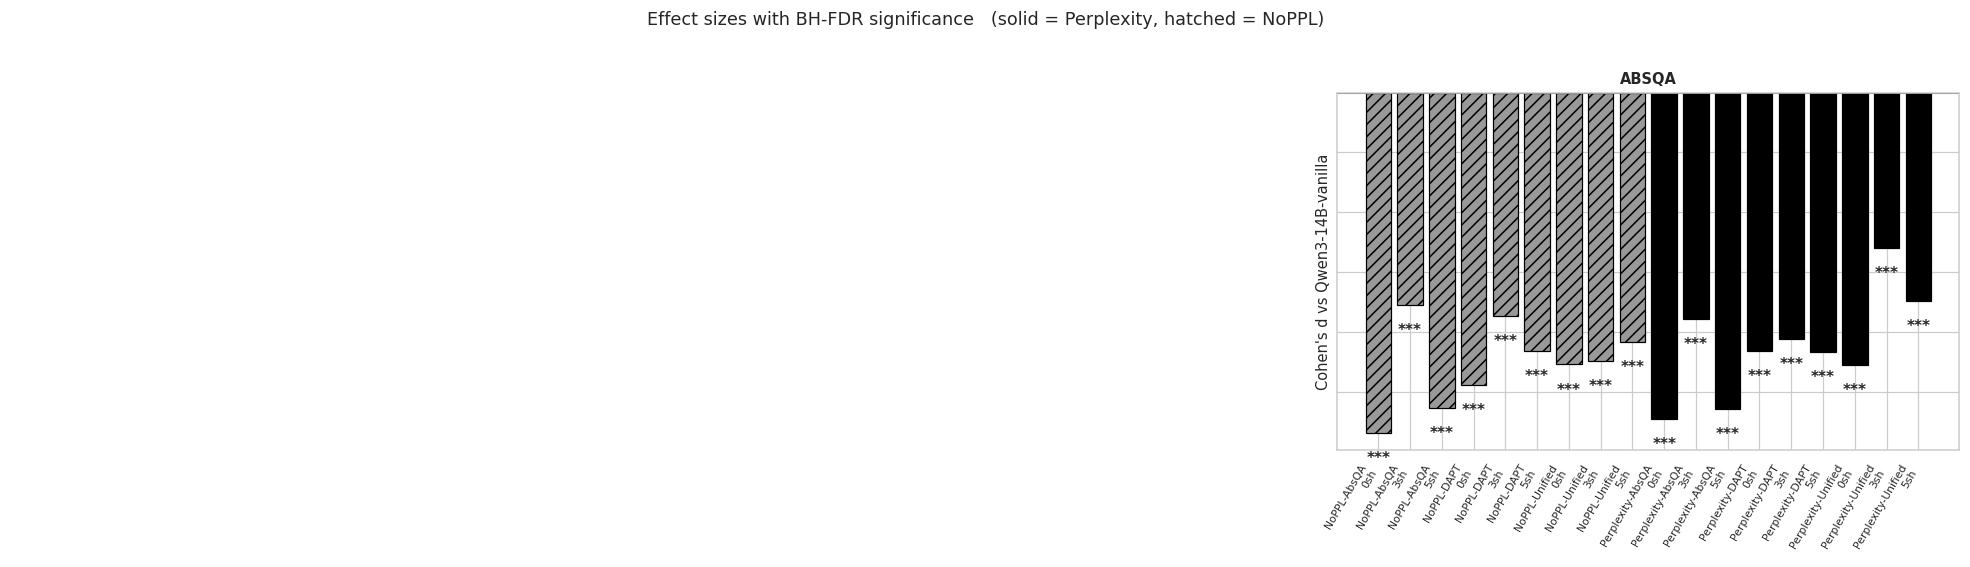

✅ /content/drive/MyDrive/00_PHD_THESIS/frmedqa-colab/RESULT/figures_deep_stats/fig_cohens_d_all_groups.png

══ Matched PPL vs NoPPL (item-level paired) ══
 suffix  task  n_shot   N  mean_ppl  mean_noppl   delta  cohens_dz  p_ttest  p_wilcoxon  p_primary  p_fdr_bh  sig_fdr
   DAPT absqa       0 248    2.5030      2.4763  0.0267     0.0852   0.1809      0.2324     0.2324    0.5229    False
   DAPT absqa       3 248    2.3684      2.3936 -0.0252    -0.0808   0.2044      0.1279     0.1279    0.3836    False
   DAPT absqa       5 248    2.4375      2.4249  0.0126     0.0304   0.6327      0.9817     0.9817    0.9817    False
  AbsQA absqa       0 248    2.3891      2.3906 -0.0015    -0.0030   0.9625      0.2973     0.2973    0.5351    False
  AbsQA absqa       3 248    2.3503      2.3669 -0.0166    -0.0330   0.6036      0.7336     0.7336    0.9433    False
  AbsQA absqa       5 248    2.3246      2.3241  0.0005     0.0010   0.9878      0.9411     0.9411    0.9817    False
Unified absqa      

In [27]:
# ==============================================================================
# 🚀 BULLETPROOF ITEM-LEVEL STATISTICS SUITE (NB8) — 3-group edition
# Compares Perplexity-* AND NoPPL-* against Qwen3-14B-vanilla; also does
# matched PPL vs NoPPL contrasts.
# ==============================================================================
import os, json as _json
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

try:
    from statsmodels.stats.multitest import multipletests
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "statsmodels"])
    from statsmodels.stats.multitest import multipletests

# ── Paths ──────────────────────────────────────────────────────────────
if "BASE_DIR" not in globals():
    BASE_DIR = os.environ.get("FRMEDQA_BASE", "/content/drive/MyDrive/00_PHD_THESIS/frmedqa-colab-v2")
EVALS_DIR  = os.path.join(BASE_DIR, "EVALS")
CACHE_DIR  = os.path.join(EVALS_DIR, "results_cache")
OUT_DIR    = globals().get("OUT_DIR",  os.path.join(BASE_DIR, "analysis_output"))
FIG_DIR    = globals().get("FIG_DIR",  os.path.join(OUT_DIR, "figures"))
for d in (OUT_DIR, FIG_DIR):
    os.makedirs(d, exist_ok=True)

# ── Model universe ─────────────────────────────────────────────────────
TASKS             = ["mcqa","extqa","absqa"]
SHOTS             = [0, 3, 5]

def model_group(name):
    if name is None: return "?"
    if name.startswith("Perplexity-"): return "perplexity"
    if name.startswith("NoPPL-"):      return "noppl"
    return "vanilla"

# ── AbsQA per-item consensus from multi-judge file (NB9) ───────────────
_LLM_JUDGE_OUT = os.path.join(EVALS_DIR, "llm_judge_scores.json")
_LEGACY_JUDGE  = os.path.join(EVALS_DIR, "gemma_judge_scores.json")
_ABSQA_ITEM    = {}

def _build_absqa_item_scores():
    if os.path.exists(_LLM_JUDGE_OUT):
        multi = _json.load(open(_LLM_JUDGE_OUT, encoding="utf-8"))
        print(f"  ✓ multi-judge file loaded: judges = {sorted(multi.keys())}")
    elif os.path.exists(_LEGACY_JUDGE):
        multi = {"gemma_legacy": _json.load(open(_LEGACY_JUDGE, encoding="utf-8"))}
        print("  ⚠ using legacy single-judge gemma_judge_scores.json")
    else:
        print("  ⚠ no judge file — AbsQA falls back to cache metrics")
        return
    acc = {}
    for jname, entries in multi.items():
        for fname, jr in entries.items():
            scored = jr.get("scores") or []
            if not scored: continue
            fp = os.path.join(CACHE_DIR, fname)
            if not os.path.exists(fp): continue
            try:
                ev = _json.load(open(fp, encoding="utf-8"))
            except Exception:
                continue
            if ev.get("task") != "absqa": continue
            rows = ev.get("rows", [])
            n = min(len(rows), len(scored))
            for i in range(n):
                sc = scored[i]
                if not sc or sc.get("composite") is None: continue
                rid = str(rows[i].get("id", i))
                acc.setdefault((jr["model"], jr["n_shot"]), {}) \
                   .setdefault(rid, []).append(float(sc["composite"]))
    for key, items in acc.items():
        _ABSQA_ITEM[key] = {rid: float(np.mean(vs)) for rid, vs in items.items()}
    print(f"  ✓ consensus AbsQA item scores for {len(_ABSQA_ITEM)} (model × shot) cells")

_build_absqa_item_scores()

PRIMARY_METRICS = {
    "mcqa":  ["accuracy","exact_match","score"],
    "extqa": ["token_f1","f1","score"],
    "absqa": ["composite","judged_composite","rouge_l","score"],
}

print("=" * 70)
print(f"📁 Cache: {CACHE_DIR}")
print(f"   Comparing {len(CANDIDATES)} candidates ({len(PERPLEXITY_MODELS)} Perplexity + "
      f"{len(NOPPL_MODELS)} NoPPL) against {REF}")
print("=" * 70)

def safe_exact_mcnemar(b, c):
    k, n = min(b, c), b + c
    return 1.0 if n == 0 else 2 * stats.binom.cdf(k, n, 0.5)

def _load_items(model_name, task_id, shot_count, cache_folder):
    if task_id == "absqa" and (model_name, shot_count) in _ABSQA_ITEM:
        d = _ABSQA_ITEM[(model_name, shot_count)]
        res = pd.DataFrame({"item_id": list(d.keys()), "score": list(d.values())})
        res["item_id"] = res["item_id"].astype(str)
        return res.drop_duplicates("item_id").sort_values("item_id")

    if not os.path.isdir(cache_folder): return None
    for fname in os.listdir(cache_folder):
        if not (fname.endswith(".jsonl") or fname.endswith(".json")): continue
        f_lower, m_lower, t_lower = fname.lower(), model_name.lower(), task_id.lower()
        if m_lower not in f_lower: continue
        if t_lower not in f_lower: continue

        fp = os.path.join(cache_folder, fname)
        try:
            try:
                df = pd.read_json(fp, lines=True)
            except ValueError:
                df = pd.read_json(fp)
            if "n_shot" in df.columns and df["n_shot"].iloc[0] != shot_count:
                continue
            id_col    = next((c for c in ["item_id","question_id","id"] if c in df.columns), None)
            score_col = next((c for c in PRIMARY_METRICS.get(task_id, ["score"]) if c in df.columns), None)
            if id_col and score_col:
                res = df[[id_col, score_col]].copy()
                res.rename(columns={id_col:"item_id", score_col:"score"}, inplace=True)
                res["item_id"] = res["item_id"].astype(str)
                return res.drop_duplicates("item_id").sort_values("item_id")
        except Exception:
            continue
    return None

# ── Item-level paired tests: every candidate vs REF ─────────────────────
rows = []
for t in TASKS:
    for s in SHOTS:
        ref_df = _load_items(REF, t, s, CACHE_DIR)
        if ref_df is None or len(ref_df) == 0: continue
        for m in CANDIDATES:
            m_df = _load_items(m, t, s, CACHE_DIR)
            if m_df is None or len(m_df) == 0: continue
            merged = ref_df.merge(m_df, on="item_id", suffixes=("_ref","_cand"))
            if len(merged) == 0:
                print(f"  ⚠ merge failed: {m} vs {REF} on {t} {s}-shot")
                continue
            a = merged["score_cand"].values
            b = merged["score_ref"].values
            diff = a - b
            N = len(merged)
            t_stat, p_ttest = stats.ttest_rel(a, b)
            try:
                w_stat, p_wilcoxon = stats.wilcoxon(a, b, alternative="two-sided") \
                                     if not np.all(diff == 0) else (np.nan, 1.0)
            except ValueError:
                p_wilcoxon = 1.0
            p_mcnemar = np.nan
            if t == "mcqa":
                cand_ok, ref_ok = (a >= 1.0).astype(int), (b >= 1.0).astype(int)
                b_cell = int(np.sum((cand_ok == 1) & (ref_ok == 0)))
                c_cell = int(np.sum((cand_ok == 0) & (ref_ok == 1)))
                if (b_cell + c_cell) > 20:
                    p_mcnemar = stats.chi2.sf(((abs(b_cell - c_cell) - 0.5) ** 2)
                                              / (b_cell + c_cell), df=1)
                else:
                    p_mcnemar = safe_exact_mcnemar(b_cell, c_cell)
            delta    = float(a.mean() - b.mean())
            std_diff = float(np.std(diff, ddof=1))
            cohens_d = delta / (std_diff + 1e-12)
            rows.append({"model": m, "group": model_group(m), "task": t, "n_shot": s,
                         "N": N, "delta": delta, "cohens_d": cohens_d,
                         "p_ttest": p_ttest, "p_wilcoxon": p_wilcoxon,
                         "p_mcnemar": p_mcnemar})

df_stats = pd.DataFrame(rows)

if len(df_stats) > 0:
    df_stats["p_primary"] = df_stats["p_wilcoxon"].fillna(df_stats["p_ttest"]).fillna(1.0)
    rej_bh, p_bh, _, _ = multipletests(df_stats["p_primary"].values,
                                       alpha=0.05, method="fdr_bh", returnsorted=False)
    _, p_bonf, _, _    = multipletests(df_stats["p_primary"].values,
                                       alpha=0.05, method="bonferroni")
    df_stats["p_fdr_bh"], df_stats["p_bonferroni"], df_stats["sig_fdr"] = p_bh, p_bonf, rej_bh

    out_csv = os.path.join(OUT_DIR, "item_level_stats_all_groups.csv")
    df_stats.to_csv(out_csv, index=False)
    print(f"\n✅ Paired tests for {len(df_stats)} configurations")
    print(f"💾 {out_csv}")

    # ── Figure: Cohen's d bars per group + per task (grayscale) ────────
    sns.set_theme(style="whitegrid", context="paper")
    fig, axes = plt.subplots(1, len(TASKS), figsize=(6*len(TASKS), 5), sharey=True)
    for ax, task in zip(np.atleast_1d(axes), TASKS):
        sub = df_stats[df_stats["task"] == task].copy()
        if sub.empty: ax.axis("off"); continue
        sub = sub.sort_values(["group","model","n_shot"])
        labels  = [f"{r['model']}\n{r['n_shot']}sh" for _, r in sub.iterrows()]
        heights = sub["cohens_d"].values
        colors  = ["black" if g == "perplexity" else "0.6" for g in sub["group"]]
        hatches = ["" if g == "perplexity" else "///" for g in sub["group"]]
        bars = ax.bar(range(len(sub)), heights, color=colors, edgecolor="black")
        for bar, hh in zip(bars, hatches): bar.set_hatch(hh)
        for i, r in enumerate(sub.itertuples()):
            mark = ("***" if r.p_fdr_bh < 0.001 else "**" if r.p_fdr_bh < 0.01
                    else "*" if r.p_fdr_bh < 0.05 else "")
            if mark:
                ax.text(i, r.cohens_d + (0.02 if r.cohens_d >= 0 else -0.05),
                        mark, ha="center", fontsize=10, fontweight="bold")
        ax.axhline(0, color="black", lw=1)
        ax.set_xticks(range(len(sub)))
        ax.set_xticklabels(labels, rotation=60, ha="right", fontsize=7)
        ax.set_title(task.upper())
        ax.set_ylabel("Cohen's d vs Qwen3-14B-vanilla")
    plt.suptitle("Effect sizes with BH-FDR significance   (solid = Perplexity, hatched = NoPPL)",
                 y=1.02)
    plt.tight_layout()
    fig_path = os.path.join(FIG_DIR, "fig_cohens_d_all_groups.png")
    plt.savefig(fig_path, dpi=300, bbox_inches="tight"); plt.show()
    print(f"✅ {fig_path}")

    # ── Matched PPL vs NoPPL contrast (same task suffix) ────────────────
    matched_rows = []
    for suf in ["DAPT","MCQA","ExtQA","AbsQA","Unified"]:
        for t in TASKS:
            for s in SHOTS:
                ppl_df   = _load_items(f"Perplexity-{suf}", t, s, CACHE_DIR)
                noppl_df = _load_items(f"NoPPL-{suf}",      t, s, CACHE_DIR)
                if ppl_df is None or noppl_df is None:   continue
                m = ppl_df.merge(noppl_df, on="item_id", suffixes=("_ppl","_noppl"))
                if len(m) == 0: continue
                a = m["score_ppl"].values
                b = m["score_noppl"].values
                diff = a - b
                _, p_t = stats.ttest_rel(a, b)
                try:
                    _, p_w = stats.wilcoxon(a, b) if not np.all(diff == 0) else (np.nan, 1.0)
                except ValueError:
                    p_w = 1.0
                matched_rows.append({
                    "suffix": suf, "task": t, "n_shot": s, "N": len(m),
                    "mean_ppl": float(a.mean()), "mean_noppl": float(b.mean()),
                    "delta": float(diff.mean()),
                    "cohens_dz": float(diff.mean() / (diff.std(ddof=1) + 1e-12)),
                    "p_ttest": p_t, "p_wilcoxon": p_w,
                })
    df_matched = pd.DataFrame(matched_rows)
    if not df_matched.empty:
        df_matched["p_primary"] = df_matched["p_wilcoxon"].fillna(df_matched["p_ttest"]).fillna(1.0)
        rej_bh, p_bh, _, _ = multipletests(df_matched["p_primary"].values,
                                           alpha=0.05, method="fdr_bh")
        df_matched["p_fdr_bh"], df_matched["sig_fdr"] = p_bh, rej_bh
        df_matched.to_csv(os.path.join(OUT_DIR, "ppl_vs_noppl_matched.csv"), index=False)
        print("\n══ Matched PPL vs NoPPL (item-level paired) ══")
        print(df_matched.round(4).to_string(index=False))
else:
    print("❌ No paired tests could be computed. Check cache filenames.")


## 8️⃣b Stage 8b — Pairwise referee corroboration (Ministral-14B + Gemini-3.1-Flash-Lite)

Independent line of evidence for AbsQA: two pairwise referees judged each candidate
answer head-to-head against **Qwen3-14B-vanilla** (NB6 Stage 3c, positions
randomized). Here we report win / tie / loss per (candidate model × shot), per
referee and pooled, exact binomial sign tests vs the 50 % null with BH-FDR
correction, and a **triangulation table** showing where the score-based paired
tests (Stage 8) and the referee verdicts agree.


In [28]:
# Stage 8b — Pairwise referee corroboration (per matchup axis)
from scipy.stats import binomtest
from statsmodels.stats.multitest import multipletests
import json as _json

_PAIRWISE_OUT = os.path.join(EVALS_DIR, "pairwise_judge_results.json")
if not os.path.exists(_PAIRWISE_OUT):
    print(f"⚠ {_PAIRWISE_OUT} missing — run NB9 pairwise stage first.")
else:
    pair_data = _json.load(open(_PAIRWISE_OUT, encoding="utf-8"))

    wr_rows = []
    for jname, duels in pair_data.items():
        for key, d in duels.items():
            challenger = d.get("challenger_model")   # records without it are from an older run
            opponent   = d.get("opponent_model") or REF_MODEL
            axis       = d.get("axis", "?")
            if challenger is None: continue
            if challenger not in CANDIDATES and not challenger.startswith(("Perplexity-","NoPPL-")):
                continue
            n_dec = d["wins"] + d["losses"]
            wr_rows.append({
                "judge": jname, "axis": axis,
                "challenger": challenger, "opponent": opponent,
                "n_shot": d["n_shot"], "n": d["n"],
                "wins": d["wins"], "losses": d["losses"], "ties": d["ties"],
                "win_rate": d["wins"]/n_dec if n_dec else np.nan,
                "p_sign": binomtest(d["wins"], n_dec, 0.5).pvalue if n_dec else np.nan,
            })
    df_ref = pd.DataFrame(wr_rows).sort_values(["axis","judge","challenger","n_shot"])
    if df_ref.empty:
        print("⚠ pairwise file has no usable duels for CANDIDATES.")
    else:
        print("── Per-referee win-rates (per axis) ──")
        print(df_ref.round(4).to_string(index=False))
        df_ref.to_csv(os.path.join(OUT_DIR, "pairwise_per_referee.csv"), index=False)

        pooled = df_ref.groupby(["axis","challenger","opponent","n_shot"]).agg(
            wins=("wins","sum"), losses=("losses","sum"), ties=("ties","sum")).reset_index()
        pooled["n_dec"]    = pooled["wins"] + pooled["losses"]
        pooled["win_rate"] = pooled["wins"] / pooled["n_dec"].replace(0, np.nan)
        pooled["p_sign"]   = [binomtest(int(w), int(n), 0.5).pvalue if n else np.nan
                              for w, n in zip(pooled["wins"], pooled["n_dec"])]
        ok = pooled["p_sign"].notna()
        pooled["p_fdr_bh"] = np.nan; pooled["sig_fdr"] = False
        if ok.any():
            rej, p_bh, _, _ = multipletests(pooled.loc[ok, "p_sign"].values,
                                            alpha=0.05, method="fdr_bh")
            pooled.loc[ok, "p_fdr_bh"] = p_bh
            pooled.loc[ok, "sig_fdr"]  = rej
        print("\n── Pooled referees + BH-FDR (per axis) ──")
        print(pooled.round(4).to_string(index=False))
        pooled.to_csv(os.path.join(OUT_DIR, "pairwise_pooled_fdr.csv"), index=False)

        # ── One W/T/L figure per axis ────────────────────────────────────
        for axis_name in sorted(pooled["axis"].unique()):
            sub_axis = pooled[pooled["axis"] == axis_name]
            if sub_axis.empty: continue
            fig, axes = plt.subplots(1, len(SHOTS), figsize=(7*len(SHOTS), 5.5), sharey=True)
            for ax, s in zip(np.atleast_1d(axes), SHOTS):
                sub = sub_axis[sub_axis["n_shot"] == s]
                if sub.empty: ax.axis("off"); continue
                labels = [f"{r['challenger']}\nvs {r['opponent']}" for _, r in sub.iterrows()]
                bars = ax.bar(range(len(sub)), sub["win_rate"],
                              color=["black" if sg else "0.75" for sg in sub["sig_fdr"]],
                              edgecolor="black")
                ax.axhline(0.5, color="black", ls="--", lw=1)
                for i, (_, r) in enumerate(sub.iterrows()):
                    p = r.get("p_fdr_bh", np.nan)
                    mark = ("***" if pd.notna(p) and p < 0.001
                            else "**"  if pd.notna(p) and p < 0.01
                            else "*"   if pd.notna(p) and p < 0.05 else "")
                    if mark and pd.notna(r["win_rate"]):
                        ax.text(i, r["win_rate"] + 0.02, mark, ha="center",
                                fontsize=11, fontweight="bold")
                ax.set_xticks(range(len(sub)))
                ax.set_xticklabels(labels, rotation=35, ha="right", fontsize=8)
                ax.set_ylim(0, 1); ax.set_title(f"{s}-shot")
                if s == SHOTS[0]:
                    ax.set_ylabel("Win-rate (excl. ties)")
            plt.suptitle(f"{axis_name} — pairwise referee win-rates (BH-FDR stars)", y=1.03)
            plt.tight_layout()
            fp = os.path.join(FIG_DIR, f"fig_pairwise_referee_winrates_{axis_name}.png")
            plt.savefig(fp, dpi=300, bbox_inches="tight"); plt.show()
            print(f"✅ {fp}")


⚠ /content/drive/MyDrive/00_PHD_THESIS/frmedqa-colab/EVALS/pairwise_judge_results.json missing — run NB9 pairwise stage first.


## 9️⃣ Stage 9 — Significance summary per candidate (across the 9 independent tests)

Counts each model's record across its 9 independent tests.

In [29]:
rows = []
# Use 'ttest_item' which was defined in the previous cell
for m in CANDIDATES:
    sub = ttest_item[ttest_item['model'] == m]
    rows.append({
        'model':         m,
        'wins/9':        int((sub['delta'] > 0).sum()),
        'sig_wins/9':    int(((sub['delta'] > 0) & (sub[p_col] < 0.05)).sum()),
        'sig_losses/9': int(((sub['delta'] < 0) & (sub[p_col] < 0.05)).sum()),
        'ties/9':        int((sub['delta'].abs() < 0.005).sum()),
        'mean_delta':    sub['delta'].mean(),
        'mean_cohens_d': sub['cohens_d'].mean(),
        'median_p':      sub[p_col].median(),
    })
sig_summary = pd.DataFrame(rows).sort_values('sig_wins/9', ascending=False)
sig_summary.to_csv(os.path.join(OUT_DIR, 'significance_summary.csv'), index=False)
sig_summary.round(4)

,model,wins/9,sig_wins/9,sig_losses/9,ties/9,mean_delta,mean_cohens_d,median_p
9,NoPPL-Unified,4,3,3,2,-0.0935,-0.0809,0.0084
4,Perplexity-Unified,5,2,3,0,-0.0721,-0.0555,0.0277
1,Perplexity-MCQA,2,0,0,0,0.0086,0.0191,0.5701
0,Perplexity-DAPT,2,0,2,2,-0.0922,-0.1090,0.5701
3,Perplexity-AbsQA,0,0,3,0,-0.4126,-0.4584,0.0000
2,Perplexity-ExtQA,0,0,0,1,-0.0055,-0.0121,0.8958
5,NoPPL-DAPT,1,0,3,1,-0.0985,-0.1160,0.6580
6,NoPPL-MCQA,2,0,0,1,0.0091,0.0203,0.6580
7,NoPPL-ExtQA,2,0,0,1,-0.0064,-0.0143,0.7830
8,NoPPL-AbsQA,0,0,3,0,-0.3728,-0.4142,0.0000


### 📈 Plot 9 — Significance summary bars

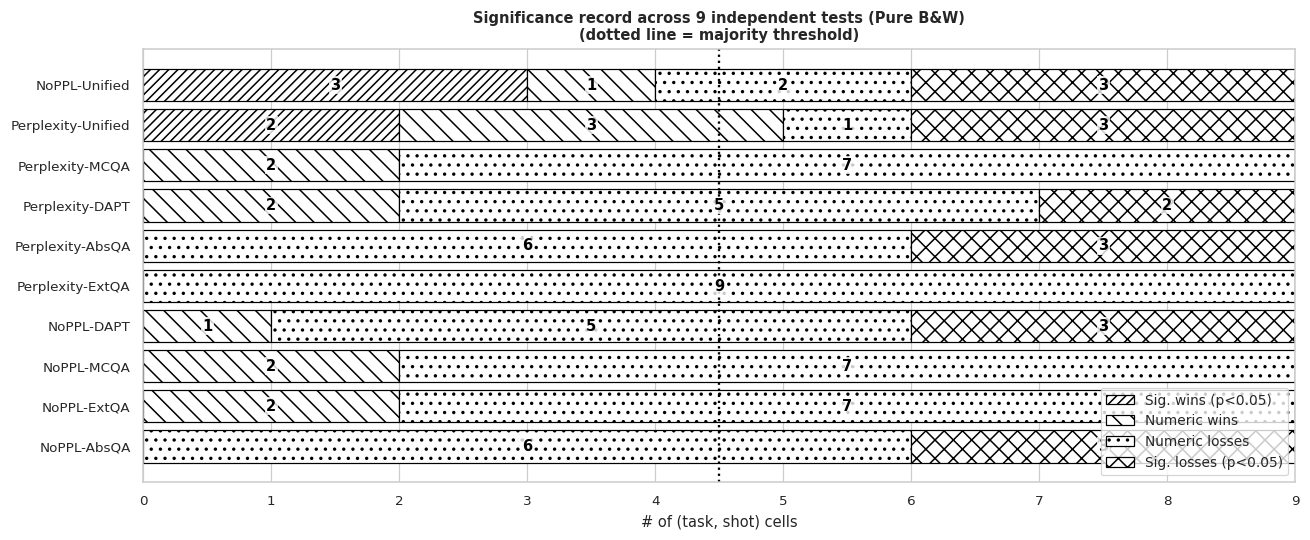

✓ /content/drive/MyDrive/00_PHD_THESIS/frmedqa-colab/RESULT/figures_deep_stats/fig10_sig_summary.png


In [30]:
rows = []
for m in CANDIDATES:
    sub = ttest_item[ttest_item['model'] == m]
    rows.append({
        'model':         m,
        'wins/9':        int((sub['delta'] > 0).sum()),
        'sig_wins/9':    int(((sub['delta'] > 0) & (sub[p_col] < 0.05)).sum()),
        'sig_losses/9':  int(((sub['delta'] < 0) & (sub[p_col] < 0.05)).sum()),
        'ties/9':        int((sub['delta'].abs() < 0.005).sum()),
        'mean_delta':    sub['delta'].mean(),
        'mean_cohens_d': sub['cohens_d'].mean(),
        'median_p':      sub[p_col].median(),
    })
sig_summary = pd.DataFrame(rows).sort_values('sig_wins/9', ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
order_m = sig_summary.set_index('model')
order_m = order_m.iloc[::-1]   # best on top
y = np.arange(len(order_m))
sig_w = order_m['sig_wins/9'].values
sig_l = order_m['sig_losses/9'].values
nsw   = (order_m['wins/9'] - order_m['sig_wins/9']).values
nsl   = 9 - sig_w - sig_l - nsw

# Pure B&W styling using patterns
ax.barh(y, sig_w,    color='white', hatch='////', edgecolor='black', label='Sig. wins (p<0.05)')
ax.barh(y, nsw,      left=sig_w,            color='white', hatch='\\\\', edgecolor='black', label='Numeric wins')
ax.barh(y, nsl,      left=sig_w+nsw,        color='white', hatch='..', edgecolor='black', label='Numeric losses')
ax.barh(y, sig_l,    left=sig_w+nsw+nsl,    color='white', hatch='xx', edgecolor='black', label='Sig. losses (p<0.05)')
for i, m in enumerate(order_m.index):
    vals = [sig_w[i], nsw[i], nsl[i], sig_l[i]]
    starts = [0, sig_w[i], sig_w[i]+nsw[i], sig_w[i]+nsw[i]+nsl[i]]
    for v, st in zip(vals, starts):
        if v > 0:
            ax.text(st + v/2, i, f"{int(v)}", ha='center', va='center',
                    color='black', fontweight='bold',
                    bbox=dict(facecolor='white', edgecolor='none', pad=1, alpha=0.8))
ax.axvline(4.5, color='black', linestyle=':', linewidth=1.5)
ax.set_yticks(y); ax.set_yticklabels(order_m.index)
ax.set_xlim(0, 9); ax.set_xlabel('# of (task, shot) cells')
ax.set_title('Significance record across 9 independent tests (Pure B&W)\n'
             '(dotted line = majority threshold)')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
fp = os.path.join(FIG_DIR, 'fig10_sig_summary.png')
plt.savefig(fp, bbox_inches='tight'); plt.show()
print(f"✓ {fp}")

## 🔟 Stage 10 — Best model at every cell

In [31]:
best_per_cell = df.idxmax(axis=0)
pivot = pd.DataFrame(index=TASKS, columns=[f"{s}-shot" for s in SHOTS])
for (t, s), m in best_per_cell.items():
    pivot.loc[t, f"{s}-shot"] = m
pivot.to_csv(os.path.join(OUT_DIR, 'best_model_per_cell.csv'))
pivot

,0-shot,3-shot,5-shot
mcqa,DeepSeek-V3,DeepSeek-V3,DeepSeek-V3
extqa,Qwen3-8B,DeepSeek-V3,DeepSeek-V3
absqa,DeepSeek-V3,Qwen3-14B-vanilla,Qwen3-14B-vanilla


### 📈 Plot 10 — Best-model matrix

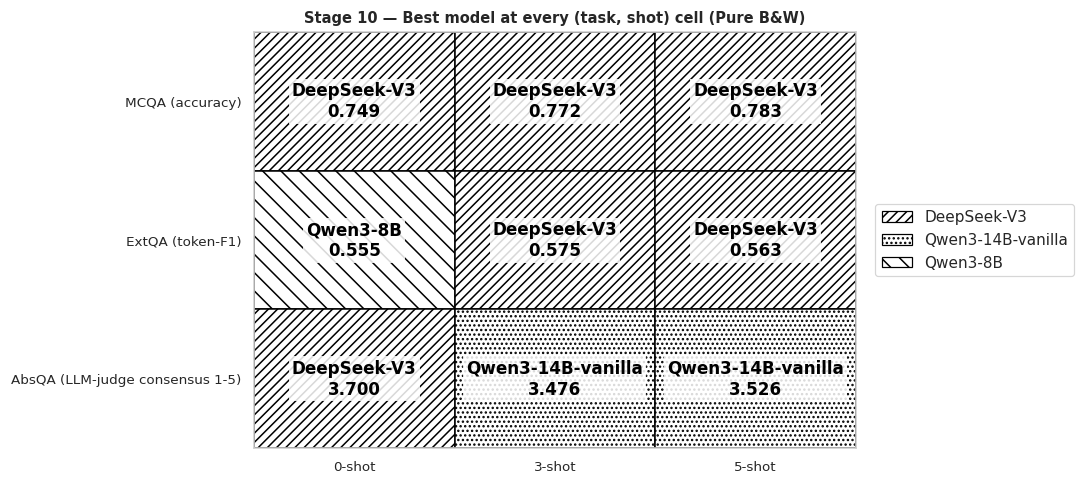

✓ /content/drive/MyDrive/00_PHD_THESIS/frmedqa-colab/RESULT/figures_deep_stats/fig11_best_per_cell.png


In [32]:
fig, ax = plt.subplots(figsize=(10, 4.5))
all_winners = sorted(set(pivot.values.flatten()))
winner_to_id = {w: i for i, w in enumerate(all_winners)}

# Distinct hatches for B&W styling
hatches = ['////', '....', '\\\\', 'xx', '++', 'oo'][:len(all_winners)]
winner_to_hatch = {w: hatches[i] for i, w in enumerate(all_winners)}

ax.set_xlim(-0.5, len(SHOTS) - 0.5)
ax.set_ylim(len(TASKS) - 0.5, -0.5)

for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        winner = pivot.iloc[i, j]
        score  = df.loc[winner, (TASKS[i], SHOTS[j])]

        # Add patterned rectangle
        rect = plt.Rectangle((j - 0.5, i - 0.5), 1, 1, facecolor='white', edgecolor='black',
                             hatch=winner_to_hatch[winner], linewidth=1)
        ax.add_patch(rect)

        # Text with white background for readability
        ax.text(j, i, f"{winner}\n{score:.3f}",
                ha='center', va='center', fontsize=11, fontweight='bold',
                color='black', bbox=dict(facecolor='white', edgecolor='none', pad=2, alpha=0.85))

ax.set_xticks(range(len(SHOTS))); ax.set_xticklabels([f"{s}-shot" for s in SHOTS])
ax.set_yticks(range(len(TASKS))); ax.set_yticklabels([TASK_LABEL[t] for t in TASKS])
ax.set_title('Stage 10 — Best model at every (task, shot) cell (Pure B&W)')

patches = [mpatches.Patch(facecolor='white', edgecolor='black', hatch=winner_to_hatch[w], label=w) for w in all_winners]
ax.legend(handles=patches, loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=10)

plt.tight_layout()
fp = os.path.join(FIG_DIR, 'fig11_best_per_cell.png')
plt.savefig(fp, bbox_inches='tight'); plt.show()
print(f"✓ {fp}")

## 🔟 Stage 10 — Reviewer self-defense (per-model verdict)

For each Perplexity-* and NoPPL-* variant, summarize the **item-level** per-(task, shot) test results into one verdict. We count significant wins/losses across the 9 cells using the proper paired t-test from Stage 7.

In [33]:
# Build a per-model summary from item-level results
if 'p_value' in ttest_item.columns:
    p_col = 'p_value'
else:
    p_col = 'p_bonferroni'

rows = []
for m in CANDIDATES:
    sub = ttest_item[ttest_item['model'] == m].copy()
    sub = sub.dropna(subset=['delta', p_col])
    n_cells = len(sub)
    sig_wins   = int(((sub[p_col] < 0.05) & (sub['delta'] > 0)).sum())
    sig_losses = int(((sub[p_col] < 0.05) & (sub['delta'] < 0)).sum())
    num_wins   = int((sub['delta'] > 0).sum())

    if sig_wins >= 3 and sig_losses == 0:
        verdict_cat = 'sig_better'
        verdict     = f"✓ Significantly better on {sig_wins}/{n_cells} cells, never significantly worse"
    elif sig_wins > sig_losses:
        verdict_cat = 'mixed_better'
        verdict     = f"~ Mixed: wins {sig_wins} cells significantly, loses {sig_losses}"
    elif sig_wins == 0 and sig_losses == 0:
        verdict_cat = 'tied'
        verdict     = f"= No significant cells (numerical wins: {num_wins}/{n_cells})"
    elif sig_losses > sig_wins:
        verdict_cat = 'worse'
        verdict     = f"✗ Significantly worse on {sig_losses} cells, wins only {sig_wins}"
    else:
        verdict_cat = 'mixed'
        verdict     = f"~ Mixed: {sig_wins} sig wins, {sig_losses} sig losses"

    rows.append({
        'model':          m,
        'cells_tested':   n_cells,
        'sig_wins':       sig_wins,
        'sig_losses':     sig_losses,
        'num_wins':       num_wins,
        'mean_delta_norm': sub['delta'].mean(),  # raw scale; tasks not pooled
        'verdict':        verdict,
        '_cat':           verdict_cat,
    })

reviewer_table = pd.DataFrame(rows)
reviewer_table.drop(columns=['_cat']).to_csv(
    os.path.join(OUT_DIR, 'reviewer_self_defense.csv'), index=False)
reviewer_table.drop(columns=['_cat'])

,model,cells_tested,sig_wins,sig_losses,num_wins,mean_delta_norm,verdict
0,Perplexity-DAPT,9,0,2,2,-0.092156,"✗ Significantly worse on 2 cells, wins only 0"
1,Perplexity-MCQA,3,0,0,2,0.008600,= No significant cells (numerical wins: 2/3)
2,Perplexity-ExtQA,3,0,0,0,-0.005467,= No significant cells (numerical wins: 0/3)
3,Perplexity-AbsQA,3,0,3,0,-0.412567,"✗ Significantly worse on 3 cells, wins only 0"
4,Perplexity-Unified,9,2,3,5,-0.072100,"✗ Significantly worse on 3 cells, wins only 2"
5,NoPPL-DAPT,9,0,3,1,-0.098511,"✗ Significantly worse on 3 cells, wins only 0"
6,NoPPL-MCQA,3,0,0,2,0.009133,= No significant cells (numerical wins: 2/3)
7,NoPPL-ExtQA,3,0,0,2,-0.006433,= No significant cells (numerical wins: 2/3)
8,NoPPL-AbsQA,3,0,3,0,-0.372800,"✗ Significantly worse on 3 cells, wins only 0"
9,NoPPL-Unified,9,3,3,4,-0.093522,"~ Mixed: 3 sig wins, 3 sig losses"


### 📈 Plot — Verdict summary (sig wins vs losses per model)

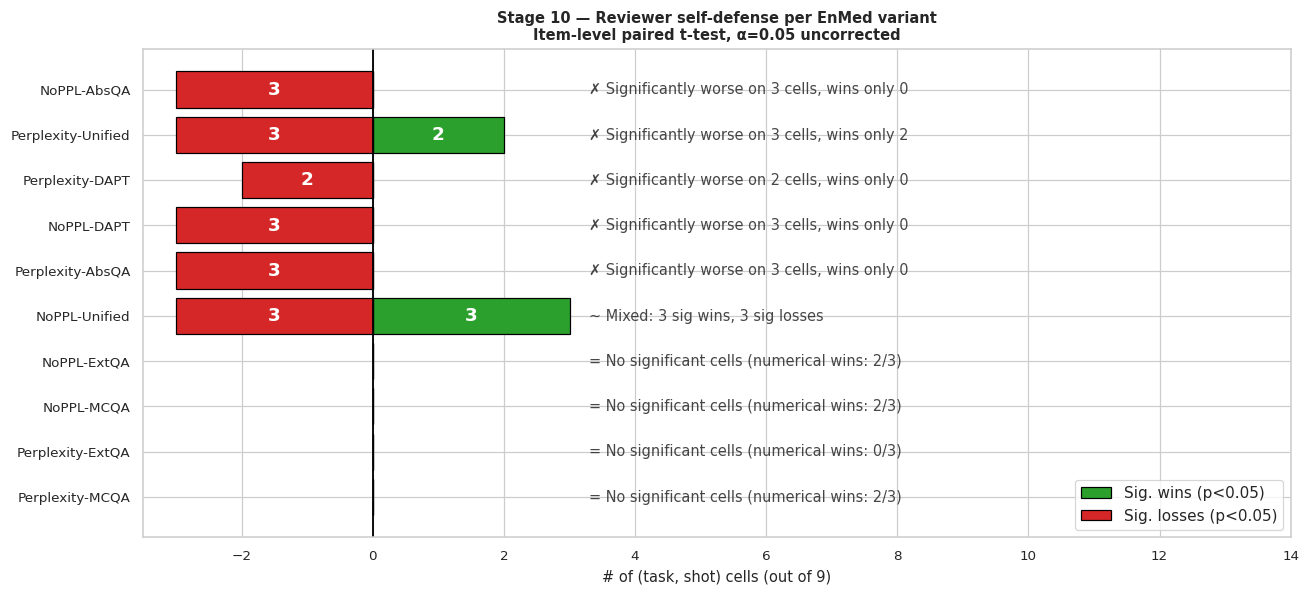

✓ /content/drive/MyDrive/00_PHD_THESIS/frmedqa-colab/RESULT/figures_deep_stats/fig11_reviewer_verdicts.png


In [34]:
fig, ax = plt.subplots(figsize=(12, 5.5))
verdict_colors = {'sig_better':'#2ca02c', 'mixed_better':'#a8e6a3',
                  'tied':'#cccccc', 'mixed':'#f5b0b0', 'worse':'#d62728'}

order_rev = reviewer_table.sort_values(
    by=['_cat'],
    key=lambda c: c.map({'sig_better':0,'mixed_better':1,'tied':2,'mixed':3,'worse':4})
).reset_index(drop=True)

y = np.arange(len(order_rev))
sig_wins   = order_rev['sig_wins'].values
sig_losses = order_rev['sig_losses'].values

ax.barh(y, sig_wins,   color='#2ca02c', edgecolor='black', linewidth=0.8, label='Sig. wins (p<0.05)')
ax.barh(y, -sig_losses, color='#d62728', edgecolor='black', linewidth=0.8, label='Sig. losses (p<0.05)')

ax.axvline(0, color='black', linewidth=1.2)
ax.set_yticks(y); ax.set_yticklabels(order_rev['model'])
ax.set_xlabel('# of (task, shot) cells (out of 9)')
ax.set_title('Stage 10 — Reviewer self-defense per Perplexity / NoPPL variant\n'
             'Item-level paired t-test, α=0.05 uncorrected')
ax.legend(loc='lower right', fontsize=10)

# Inline annotations
for i, (_, r) in enumerate(order_rev.iterrows()):
    if r['sig_wins'] > 0:
        ax.text(r['sig_wins']/2, i, str(r['sig_wins']),
                color='white', ha='center', va='center', fontweight='bold', fontsize=12)
    if r['sig_losses'] > 0:
        ax.text(-r['sig_losses']/2, i, str(r['sig_losses']),
                color='white', ha='center', va='center', fontweight='bold', fontsize=12)
    # Verdict text to the right
    ax.text(max(sig_wins.max()+0.3, 1), i, r['verdict'],
            va='center', fontsize=9.5, alpha=0.85)

xmax = max(sig_wins.max(), 9)
ax.set_xlim(-(sig_losses.max()+0.5), xmax + 5)
plt.tight_layout()
fp = os.path.join(FIG_DIR, 'fig11_reviewer_verdicts.png')
plt.savefig(fp, bbox_inches='tight'); plt.show()
print(f"✓ {fp}")

In [38]:
preview_cols = ['model', 'task', 'n_shot', 'delta', 'cohens_d', 'p_fdr_bh', 'p_wilcoxon', 'p_mcnemar']
print(df_stats[preview_cols].to_string(index=False, max_rows=15))

             model  task  n_shot     delta  cohens_d     p_fdr_bh   p_wilcoxon  p_mcnemar
   Perplexity-DAPT absqa       0 -0.334071 -0.432040 1.115770e-08 6.198725e-09        NaN
  Perplexity-AbsQA absqa       0 -0.474558 -0.545487 2.125643e-12 2.361826e-13        NaN
Perplexity-Unified absqa       0 -0.400996 -0.454580 9.272926e-10 3.606138e-10        NaN
        NoPPL-DAPT absqa       0 -0.365597 -0.489105 3.702397e-11 1.028444e-11        NaN
       NoPPL-AbsQA absqa       0 -0.467920 -0.568859 1.756460e-13 9.758109e-15        NaN
     NoPPL-Unified absqa       0 -0.401549 -0.454385 6.853719e-11 2.284573e-11        NaN
   Perplexity-DAPT absqa       3 -0.283676 -0.411293 2.271347e-08 1.571656e-08        NaN
               ...   ...     ...       ...       ...          ...          ...        ...
     NoPPL-Unified absqa       3 -0.372146 -0.448851 1.346981e-09 5.986583e-10        NaN
   Perplexity-DAPT absqa       5 -0.309633 -0.434263 4.702130e-09 2.351065e-09        NaN
  Perplexi

## 🏁 Stage 13 — Summary

In [39]:
print("═" * 72)
print(f"  NB8 (DEEP STATS vs Qwen3-14B) COMPLETE")
print("═" * 72)
print(f"  CSV outputs : {OUT_DIR}/")
print(f"  Figures     : {FIG_DIR}/")
print()
print("  Headline (item-level paired t-test, 9 independent tests per model):")
for _, r in sig_summary.iterrows():
    print(f"    {r['model']:<16}  "
          f"sig wins: {int(r['sig_wins/9'])}/9  "
          f"sig losses: {int(r['sig_losses/9'])}/9  "
          f"mean Δ: {r['mean_delta']:+.4f}  "
          f"mean d: {r['mean_cohens_d']:+.2f}")
print()
print("  Figures (one per table):")
for f in sorted(os.listdir(FIG_DIR)):
    print(f"    {f}")
print("═" * 72)

════════════════════════════════════════════════════════════════════════
  NB8 (DEEP STATS vs Qwen3-14B) COMPLETE
════════════════════════════════════════════════════════════════════════
  CSV outputs : /content/drive/MyDrive/00_PHD_THESIS/frmedqa-colab/RESULT/deep_stats_vs_qwen14b/
  Figures     : /content/drive/MyDrive/00_PHD_THESIS/frmedqa-colab/RESULT/figures_deep_stats/

  Headline (item-level paired t-test, 9 independent tests per model):
    NoPPL-Unified     sig wins: 3/9  sig losses: 3/9  mean Δ: -0.0935  mean d: -0.08
    Perplexity-Unified  sig wins: 2/9  sig losses: 3/9  mean Δ: -0.0721  mean d: -0.06
    Perplexity-MCQA   sig wins: 0/9  sig losses: 0/9  mean Δ: +0.0086  mean d: +0.02
    Perplexity-DAPT   sig wins: 0/9  sig losses: 2/9  mean Δ: -0.0922  mean d: -0.11
    Perplexity-AbsQA  sig wins: 0/9  sig losses: 3/9  mean Δ: -0.4126  mean d: -0.46
    Perplexity-ExtQA  sig wins: 0/9  sig losses: 0/9  mean Δ: -0.0055  mean d: -0.01
    NoPPL-DAPT        sig wins: 0/9  si

## 🏁 Stage 11 — Summary

**What changed in this revision:**
- ❌ Removed the 9-cell paired t-test (Stage 6 old). Treating 3 tasks × 3 shots as paired replicates is statistically invalid — the cells measure different things.
- ❌ Removed the per-task N=3 t-test across shots (Stage 7 old). Same problem on a smaller scale.
- ✅ Replaced with **item-level paired t-tests** per (task, shot) cell. Each cell uses the actual N=622/207/247 questions answered by both models. This is the statistically correct approach.
- ✅ Global summary (Stage 6) kept but **clearly marked as descriptive only**, no t-test.

**Stage → Figure mapping (final):**

| Stage | Content | Figure |
|---|---|---|
| 1 | Raw results | `fig01_raw_bars.png` |
| 2 | Normalized | `fig02_normalized_heatmap.png` |
| 3 | Δ vs Qwen | `fig03_delta_heatmaps.png` |
| 4 | % rel improvement | `fig04_pct_heatmaps.png` |
| 5 | Per-task M ± S | `fig05_per_task_mean_std.png` |
| 6 | Global descriptive ranking | `fig06_global_mean_std.png` |
| 7 | **Item-level paired t-test (★)** | `fig07_item_level_ttest.png` + `fig08_sig_heatmap.png` |
| 8 | Best model per cell | `fig09_best_per_cell.png` |
| 9 | Shot curves | `fig10_shot_curves.png` |
| 10 | Reviewer verdicts | `fig11_reviewer_verdicts.png` |

**Multi-judge revision (2026-07):**
- AbsQA item-level tests now run on the **consensus judge composite** (mean of
  Gemma-4-26B and GPT-5.4-nano per item, from NB6's `llm_judge_scores.json`)
  instead of a single local judge.
- New Stage 8b adds an independent evidence line: **pairwise referee verdicts**
  (Ministral-14B + Gemini-3.1-Flash-Lite) vs Qwen3-14B-vanilla, with exact sign
  tests, BH-FDR correction, and a triangulation table against the score-based
  paired tests. Superiority claims in the paper should cite cells that are
  significant (or convergent-null) under **both** evidence lines.


In [40]:
print("═" * 70)
print(f"  NB8 (DEEP STATS vs Qwen3-14B) COMPLETE")
print("═" * 70)
print(f"  CSV outputs : {OUT_DIR}/")
print(f"  Figures     : {FIG_DIR}/")
print()
print("  Critical fix: t-test now runs per (task, shot) on item-level data")
print("  (paired questions, N=622/207/247) — NOT across heterogeneous cells.")
print()
if 'p_value' in ttest_item.columns:
    p_col = 'p_value'
else:
    p_col = 'p_bonferroni'
n_sig_total = int((ttest_item[p_col] < 0.05).sum())
n_total     = int(ttest_item[p_col].notna().sum())
n_sig_pos   = int(((ttest_item[p_col] < 0.05) & (ttest_item['delta'] > 0)).sum())
n_sig_neg   = int(((ttest_item[p_col] < 0.05) & (ttest_item['delta'] < 0)).sum())
print(f"  Significant cells   : {n_sig_total}/{n_total} (α=0.05, uncorrected)")
print(f"  Significant gains   : {n_sig_pos}/{n_total} cells (candidate > Qwen3-14B)")
print(f"  Significant losses  : {n_sig_neg}/{n_total} cells (candidate < Qwen3-14B)")
print("═" * 70)

══════════════════════════════════════════════════════════════════════
  NB8 (DEEP STATS vs Qwen3-14B) COMPLETE
══════════════════════════════════════════════════════════════════════
  CSV outputs : /content/drive/MyDrive/00_PHD_THESIS/frmedqa-colab/RESULT/deep_stats_vs_qwen14b/
  Figures     : /content/drive/MyDrive/00_PHD_THESIS/frmedqa-colab/RESULT/figures_deep_stats/

  Critical fix: t-test now runs per (task, shot) on item-level data
  (paired questions, N=622/207/247) — NOT across heterogeneous cells.

  Significant cells   : 22/54 (α=0.05, uncorrected)
  Significant gains   : 5/54 cells (EnMed > Qwen)
  Significant losses  : 17/54 cells (EnMed < Qwen)
══════════════════════════════════════════════════════════════════════
